#Senior Data Scientist

Sevgi Merve Aksu

In [ ]:
# Here we connect to our google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Here we change the working diretory
import os
#Here we change our directory to the main folder to read the files
os.chdir('/content/drive/My Drive/Data')

#1. Reading and Organizing Electricity Consumption, Date, and Meteorological Data

*   First, we read each .csv and .xslx file individually
*   Then, we preprocess each data, which includes data imputation, and aggregation



In [ ]:
# Here we read all the data and merge them
import pandas as pd

# Here we list all the file paths for csv files
meteorology_file_path = 'Meteological_Veri.csv'
train1_file_path = 'TrainData1.csv'
train2_file_path = 'TrainData2.csv'

# Read the CSV file into a pandas DataFrame
try:
  df_meteo = pd.read_csv(meteorology_file_path, sep=';', encoding = 'ISO-8859-9')
  df_train1 = pd.read_csv(train1_file_path, sep=',', encoding = 'ISO-8859-9')
  df_train2 = pd.read_csv(train2_file_path, sep=',', encoding = 'ISO-8859-9')
  print("CSV files read successfully.")
except Exception as e:
  print(f"An error occurred while reading the CSV file: {e}")

# Here we filter df_meteo to only relevant columns
meteo_columns = ['Date',	'Hour',	'Location',	'AirTemperature',	'ComfortTemperature',
                   'RelativeHumidity',	'WindSpeed',	'WindDirection',	'EffectiveCloudCover',
                   'Precipitationheight',	'Forecast/Actual']
df_meteo = df_meteo[meteo_columns]

# Here we concatenate two training data
df_train = pd.concat([df_train1, df_train2], ignore_index=True)

df_train.head()

/tmp/ipython-input-3-2721311159.py:11: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meteo = pd.read_csv(meteorology_file_path, sep=';', encoding = 'ISO-8859-9')


CSV files read successfully.


,BOLGE,Sehir,DataDate,ConsumptionH1,ConsumptionH2,ConsumptionH3,ConsumptionH4,ConsumptionH5,ConsumptionH6,ConsumptionH7,...,ConsumptionH16,ConsumptionH17,ConsumptionH18,ConsumptionH19,ConsumptionH20,ConsumptionH21,ConsumptionH22,ConsumptionH23,ConsumptionH24,Kod_ID
0,TOROSLAR,Antalya,2024-05-29,743.4,711.9,636.3,680.4,642.6,648.9,1215.9,...,1058.4,1146.6,1335.6,1436.4,1619.1,1587.6,1291.5,1190.7,1159.2,1
1,TOROSLAR,Antalya,2024-05-30,970.2,743.4,598.5,598.5,636.3,674.1,762.3,...,1278.9,932.4,1102.5,1253.7,1423.8,1152.9,1234.8,1171.8,957.6,1
2,TOROSLAR,Antalya,2024-05-31,648.9,630.0,592.2,598.5,598.5,617.4,686.7,...,837.9,875.7,1058.4,1228.5,1335.6,1404.9,1304.1,1228.5,1102.5,1
3,TOROSLAR,Antalya,2024-06-01,756.0,667.8,604.8,630.0,617.4,611.1,667.8,...,875.7,932.4,1089.9,1228.5,1367.1,1398.6,1297.8,1203.3,1127.7,1
4,TOROSLAR,Antalya,2024-06-02,749.7,661.5,642.6,630.0,661.5,630.0,680.4,...,982.8,963.9,1146.6,1297.8,1367.1,1449.0,1335.6,1241.1,1127.7,1


In [ ]:
# Here we read xlsx file for dates
date_file_path = 'Takvim_Verileri.xlsx'

# Read the CSV file into a pandas DataFrame
try:
  df_takvim = pd.read_excel(date_file_path)
  print("XLSX files read successfully.")
except Exception as e:
  print(f"An error occurred while reading the XLSX file: {e}")

# Here we filter df_takvimn to only relevant columns
takvim_columns = ['DATE',	'OFFICIAL_HOLIDAY',	'RELIGIOUS_HOLIDAY',	'Weekday_N',
                  'Weekend_N',	'NEW_DAY_TYPE',	'NEW_DAY_TYPE_TXT',	'ACTUAL_HOLIDAYS']
df_takvim = df_takvim[takvim_columns]

df_takvim.head()

XLSX files read successfully.


,DATE,OFFICIAL_HOLIDAY,RELIGIOUS_HOLIDAY,Weekday_N,Weekend_N,NEW_DAY_TYPE,NEW_DAY_TYPE_TXT,ACTUAL_HOLIDAYS
0,2024-05-29,0,0,1,0,3,Wednesday,0
1,2024-05-30,0,0,1,0,4,Thursday,0
2,2024-05-31,0,0,1,0,5,Friday,0
3,2024-06-01,0,0,0,1,6,Saturday,0
4,2024-06-02,0,0,0,1,7,Sunday,0


##1.1 Data Imputation for missing data

In [ ]:
# Here we count the missing data for the meteorological data
missing_meteo = df_meteo.isnull().sum()
print(missing_meteo)
print("Total Rows in Meteorology Data",len(df_meteo))

Date                       0
Hour                       0
Location                   0
AirTemperature             0
ComfortTemperature         0
RelativeHumidity           0
WindSpeed                  0
WindDirection              0
EffectiveCloudCover        0
Precipitationheight    58400
Forecast/Actual            0
dtype: int64
Total Rows in Meteorology Data 72768


In [ ]:
# Here we count the missing data for the training data
missing_train = df_train.isnull().sum()
print(missing_train)
print("Total Rows in Training Data",len(df_train))

BOLGE                0
Sehir                0
DataDate             0
ConsumptionH1     1622
ConsumptionH2     1747
ConsumptionH3     1679
ConsumptionH4     1612
ConsumptionH5     1615
ConsumptionH6     1584
ConsumptionH7     1545
ConsumptionH8     1561
ConsumptionH9     1593
ConsumptionH10    1989
ConsumptionH11    2042
ConsumptionH12    2049
ConsumptionH13    1992
ConsumptionH14    1848
ConsumptionH15    1765
ConsumptionH16    1740
ConsumptionH17    1606
ConsumptionH18    1566
ConsumptionH19    1638
ConsumptionH20    1602
ConsumptionH21    1579
ConsumptionH22    1629
ConsumptionH23    1617
ConsumptionH24    1641
Kod_ID               0
dtype: int64
Total Rows in Training Data 1226178


In [ ]:
# Here we count the missing data for the takvim data
missing_takvim = df_takvim.isnull().sum()
print(missing_takvim)
print("Total Rows in Takvim Data",len(df_takvim))

DATE                 0
OFFICIAL_HOLIDAY     0
RELIGIOUS_HOLIDAY    0
Weekday_N            0
Weekend_N            0
NEW_DAY_TYPE         0
NEW_DAY_TYPE_TXT     0
ACTUAL_HOLIDAYS      0
dtype: int64
Total Rows in Takvim Data 398


In [ ]:
# Here we merge the training data and takvim data for the data imputation
# Convert 'DataDate' in df_train to datetime objects
df_train['DataDate'] = pd.to_datetime(df_train['DataDate'])
# Here we merge them based on the date
df_train_takvim = pd.merge(df_takvim, df_train, left_on='DATE', right_on='DataDate', how='inner')

df_train_takvim.head()

,DATE,OFFICIAL_HOLIDAY,RELIGIOUS_HOLIDAY,Weekday_N,Weekend_N,NEW_DAY_TYPE,NEW_DAY_TYPE_TXT,ACTUAL_HOLIDAYS,BOLGE,Sehir,...,ConsumptionH16,ConsumptionH17,ConsumptionH18,ConsumptionH19,ConsumptionH20,ConsumptionH21,ConsumptionH22,ConsumptionH23,ConsumptionH24,Kod_ID
0,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Antalya,...,1058.400,1146.600,1335.600,1436.400,1619.100,1587.600,1291.500,1190.700,1159.200,1
1,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Mugla,...,21.640,24.640,25.000,26.440,22.120,22.360,22.720,22.360,22.240,718
2,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Mugla,...,938.700,894.600,891.450,900.900,910.350,916.650,894.600,787.500,752.850,1936
3,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Mersin,...,1569.709,1632.109,1627.046,1511.857,1531.055,1401.467,1247.882,527.869,321.520,1937
4,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Antalya,...,768.602,778.052,746.552,752.852,765.452,752.852,689.852,661.502,636.302,1938


In [ ]:
# Here we count the missing data for the merged training data
missing_train = df_train_takvim.isnull().sum()
print(missing_train)
print("Total Rows in Merged Training Data",len(df_train_takvim))

DATE                    0
OFFICIAL_HOLIDAY        0
RELIGIOUS_HOLIDAY       0
Weekday_N               0
Weekend_N               0
NEW_DAY_TYPE            0
NEW_DAY_TYPE_TXT        0
ACTUAL_HOLIDAYS         0
BOLGE                   0
Sehir                   0
DataDate                0
ConsumptionH1        1622
ConsumptionH2        1747
ConsumptionH3        1679
ConsumptionH4        1612
ConsumptionH5        1615
ConsumptionH6        1584
ConsumptionH7        1545
ConsumptionH8        1561
ConsumptionH9        1593
ConsumptionH10       1989
ConsumptionH11       2042
ConsumptionH12       2049
ConsumptionH13       1992
ConsumptionH14       1848
ConsumptionH15       1765
ConsumptionH16       1740
ConsumptionH17       1606
ConsumptionH18       1566
ConsumptionH19       1638
ConsumptionH20       1602
ConsumptionH21       1579
ConsumptionH22       1629
ConsumptionH23       1617
ConsumptionH24       1641
Kod_ID                  0
dtype: int64
Total Rows in Merged Training Data 1226178


In [ ]:
# Map month to numeric season
def get_season(month):
  """
    This function maps month to numeric season.
  """

  if month in [12, 1, 2]:
      return 1  # Winter
  elif month in [3, 4, 5]:
      return 2  # Spring
  elif month in [6, 7, 8]:
      return 3  # Summer
  elif month in [9, 10, 11]:
      return 4  # Fall


In [ ]:
# Here we impute the missing data based on its average on Kod_ID, NEW_DAY_TYPE, and SEASON

# Extract numeric month
df_train_takvim['MONTH'] = df_train_takvim['DATE'].dt.month

# Here we create a SEASON column for the data imputation
df_train_takvim['SEASON'] = df_train_takvim['MONTH'].apply(get_season)

# Here we list the consumption hours so that we can impute them all
consumption_hours = ['ConsumptionH1', 'ConsumptionH2', 'ConsumptionH3', 'ConsumptionH4', 'ConsumptionH5',
                     'ConsumptionH6', 'ConsumptionH7', 'ConsumptionH8', 'ConsumptionH9', 'ConsumptionH10',
                     'ConsumptionH11', 'ConsumptionH12', 'ConsumptionH13', 'ConsumptionH14', 'ConsumptionH15',
                     'ConsumptionH16', 'ConsumptionH17', 'ConsumptionH18', 'ConsumptionH19', 'ConsumptionH20',
                     'ConsumptionH21', 'ConsumptionH22', 'ConsumptionH23', 'ConsumptionH24']

# Calculate group means and fill NaNs with them
for hour in consumption_hours:
  df_train_takvim[hour] = df_train_takvim[hour].fillna(df_train_takvim.groupby(['Kod_ID',
                                                                                         'Weekday_N', 'SEASON'])[hour].transform('mean'))

# Here we count the missing data for the merged training data
missing_train = df_train_takvim.isnull().sum()
print(missing_train)

DATE                  0
OFFICIAL_HOLIDAY      0
RELIGIOUS_HOLIDAY     0
Weekday_N             0
Weekend_N             0
NEW_DAY_TYPE          0
NEW_DAY_TYPE_TXT      0
ACTUAL_HOLIDAYS       0
BOLGE                 0
Sehir                 0
DataDate              0
ConsumptionH1        16
ConsumptionH2        16
ConsumptionH3        16
ConsumptionH4        16
ConsumptionH5        16
ConsumptionH6        16
ConsumptionH7         0
ConsumptionH8         0
ConsumptionH9         0
ConsumptionH10        0
ConsumptionH11        0
ConsumptionH12        0
ConsumptionH13        0
ConsumptionH14        0
ConsumptionH15        0
ConsumptionH16        0
ConsumptionH17        0
ConsumptionH18        0
ConsumptionH19        0
ConsumptionH20        0
ConsumptionH21        0
ConsumptionH22        0
ConsumptionH23        0
ConsumptionH24        0
Kod_ID                0
MONTH                 0
SEASON                0
dtype: int64


In [ ]:
# Here we check the rows with missing data to see its volume
rows_with_missing = df_train_takvim[df_train_takvim.isnull().any(axis=1)]
rows_with_missing[consumption_hours].head(16)

,ConsumptionH1,ConsumptionH2,ConsumptionH3,ConsumptionH4,ConsumptionH5,ConsumptionH6,ConsumptionH7,ConsumptionH8,ConsumptionH9,ConsumptionH10,...,ConsumptionH15,ConsumptionH16,ConsumptionH17,ConsumptionH18,ConsumptionH19,ConsumptionH20,ConsumptionH21,ConsumptionH22,ConsumptionH23,ConsumptionH24
1037231,NaN,NaN,NaN,NaN,NaN,NaN,0.42,0.38,1.56,0.600,...,0.400000,0.400000,1.200000,0.400000,0.300000,0.518,0.50,0.665,0.04,0.324
1040945,NaN,NaN,NaN,NaN,NaN,NaN,0.42,0.38,1.56,1.995,...,1.190769,1.123636,0.080000,0.978333,0.380000,0.520,0.40,0.340,0.74,0.324
1063274,NaN,NaN,NaN,NaN,NaN,NaN,0.42,0.38,1.60,1.800,...,1.840000,2.740000,1.500000,2.400000,1.980000,0.160,0.50,0.665,0.74,0.324
1066991,NaN,NaN,NaN,NaN,NaN,NaN,0.42,0.38,1.56,1.995,...,1.190769,1.123636,1.024615,0.978333,0.240000,0.340,0.50,0.800,1.12,1.100
1089344,NaN,NaN,NaN,NaN,NaN,NaN,0.42,0.38,1.20,2.200,...,1.980000,0.700000,0.980000,0.420000,2.000000,0.518,0.50,0.440,0.74,0.324
1093062,NaN,NaN,NaN,NaN,NaN,NaN,0.42,0.38,1.56,1.995,...,0.140000,1.123636,1.024615,0.978333,0.847692,0.518,0.50,0.665,0.74,0.160
1115389,NaN,NaN,NaN,NaN,NaN,NaN,0.42,0.08,1.48,2.520,...,0.720000,0.860000,0.860000,0.620000,0.847692,0.518,0.50,0.665,0.74,0.324
1119106,NaN,NaN,NaN,NaN,NaN,NaN,0.42,0.38,1.56,1.995,...,0.740000,0.500000,0.440000,0.400000,0.420000,0.420,0.40,0.400,0.74,0.324
1140582,NaN,NaN,NaN,NaN,NaN,NaN,0.42,0.38,1.46,3.220,...,1.900000,1.720000,2.100000,1.740000,1.300000,0.518,0.28,0.080,0.74,0.324
1143970,NaN,NaN,NaN,NaN,NaN,NaN,0.42,0.38,1.56,1.995,...,0.780000,1.123636,0.440000,0.460000,0.580000,2.160,1.44,1.780,1.06,0.324


In [ ]:
# Given its low level consumption, it could be removed from the training data
df_train_takvim.dropna(inplace=True)

# Here we count the missing data for the merged training data
missing_train = df_train_takvim.isnull().sum()
print(missing_train)
print("Total Rows in Merged Training Data",len(df_train_takvim))

df_train_takvim.head()


DATE                 0
OFFICIAL_HOLIDAY     0
RELIGIOUS_HOLIDAY    0
Weekday_N            0
Weekend_N            0
NEW_DAY_TYPE         0
NEW_DAY_TYPE_TXT     0
ACTUAL_HOLIDAYS      0
BOLGE                0
Sehir                0
DataDate             0
ConsumptionH1        0
ConsumptionH2        0
ConsumptionH3        0
ConsumptionH4        0
ConsumptionH5        0
ConsumptionH6        0
ConsumptionH7        0
ConsumptionH8        0
ConsumptionH9        0
ConsumptionH10       0
ConsumptionH11       0
ConsumptionH12       0
ConsumptionH13       0
ConsumptionH14       0
ConsumptionH15       0
ConsumptionH16       0
ConsumptionH17       0
ConsumptionH18       0
ConsumptionH19       0
ConsumptionH20       0
ConsumptionH21       0
ConsumptionH22       0
ConsumptionH23       0
ConsumptionH24       0
Kod_ID               0
MONTH                0
SEASON               0
dtype: int64
Total Rows in Merged Training Data 1226162


,DATE,OFFICIAL_HOLIDAY,RELIGIOUS_HOLIDAY,Weekday_N,Weekend_N,NEW_DAY_TYPE,NEW_DAY_TYPE_TXT,ACTUAL_HOLIDAYS,BOLGE,Sehir,...,ConsumptionH18,ConsumptionH19,ConsumptionH20,ConsumptionH21,ConsumptionH22,ConsumptionH23,ConsumptionH24,Kod_ID,MONTH,SEASON
0,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Antalya,...,1335.600,1436.400,1619.100,1587.600,1291.500,1190.700,1159.200,1,5,2
1,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Mugla,...,25.000,26.440,22.120,22.360,22.720,22.360,22.240,718,5,2
2,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Mugla,...,891.450,900.900,910.350,916.650,894.600,787.500,752.850,1936,5,2
3,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Mersin,...,1627.046,1511.857,1531.055,1401.467,1247.882,527.869,321.520,1937,5,2
4,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Antalya,...,746.552,752.852,765.452,752.852,689.852,661.502,636.302,1938,5,2


In [ ]:
# Here we aggregate the data based on takvim, Sehir
agg_columns = ['DATE',	'OFFICIAL_HOLIDAY',	'RELIGIOUS_HOLIDAY',	'Weekday_N',
               'Weekend_N',	'NEW_DAY_TYPE',	'NEW_DAY_TYPE_TXT',	'ACTUAL_HOLIDAYS',	'BOLGE',	'Sehir']
# Sum consumption based on cities
df_train_agg = df_train_takvim.groupby(agg_columns)[consumption_hours].sum().reset_index()

# Here we count the missing data for the aggreageted training data
missing_train = df_train_agg.isnull().sum()
print(missing_train)
print("Total Rows in Aggregated Training Data",len(df_train_agg))

df_train_agg.head(60)

DATE                 0
OFFICIAL_HOLIDAY     0
RELIGIOUS_HOLIDAY    0
Weekday_N            0
Weekend_N            0
NEW_DAY_TYPE         0
NEW_DAY_TYPE_TXT     0
ACTUAL_HOLIDAYS      0
BOLGE                0
Sehir                0
ConsumptionH1        0
ConsumptionH2        0
ConsumptionH3        0
ConsumptionH4        0
ConsumptionH5        0
ConsumptionH6        0
ConsumptionH7        0
ConsumptionH8        0
ConsumptionH9        0
ConsumptionH10       0
ConsumptionH11       0
ConsumptionH12       0
ConsumptionH13       0
ConsumptionH14       0
ConsumptionH15       0
ConsumptionH16       0
ConsumptionH17       0
ConsumptionH18       0
ConsumptionH19       0
ConsumptionH20       0
ConsumptionH21       0
ConsumptionH22       0
ConsumptionH23       0
ConsumptionH24       0
dtype: int64
Total Rows in Aggregated Training Data 14808


,DATE,OFFICIAL_HOLIDAY,RELIGIOUS_HOLIDAY,Weekday_N,Weekend_N,NEW_DAY_TYPE,NEW_DAY_TYPE_TXT,ACTUAL_HOLIDAYS,BOLGE,Sehir,...,ConsumptionH15,ConsumptionH16,ConsumptionH17,ConsumptionH18,ConsumptionH19,ConsumptionH20,ConsumptionH21,ConsumptionH22,ConsumptionH23,ConsumptionH24
0,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Adana,...,124782.858943,121827.354682,116940.767324,108477.077896,97950.029535,97976.812869,100062.495652,99825.111675,99170.587420,96017.024101
1,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Amasya,...,1663.200000,1701.000000,1713.600000,1688.400000,1675.800000,1738.800000,1751.400000,1764.000000,1713.600000,1688.400000
2,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Ankara,...,677.994000,659.470000,650.932000,586.258000,462.387000,434.965000,451.965000,435.107000,414.596000,410.540000
3,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Antalya,...,32850.106800,31895.092800,30426.600800,29377.072800,29174.120800,28713.353800,28253.138800,27318.042800,26452.808800,25400.348800
4,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Bingol,...,3.300000,4.950000,3.300000,4.950000,3.300000,6.600000,3.300000,3.300000,3.300000,4.950000
5,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Bitlis,...,30.618000,8.304000,22.373000,49.654000,78.582000,33.563000,1.120000,1.120000,6.171000,1.120000
6,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Bursa,...,13.960000,13.000000,39.640000,12.640000,15.520000,10.120000,9.760000,11.440000,25.360000,8.680000
7,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Cankiri,...,6.431000,6.182000,8.334000,5.025000,3.964000,5.681000,12.595000,12.713000,12.370000,14.701000
8,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Diyarbakir,...,297.152000,268.033000,316.297000,287.148000,156.894000,140.550000,144.742000,143.160000,161.218000,187.880000
9,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Edirne,...,38.220000,30.600000,29.340000,27.360000,25.920000,25.140000,17.940000,3.780000,3.780000,3.780000


#2. Data Exploration

In [ ]:
# Here we aggregate data for TOROS region to check patterns for each day type and month
agg_columns = ['DATE',  'OFFICIAL_HOLIDAY',     'RELIGIOUS_HOLIDAY',    'Weekday_N',
               'Weekend_N',     'NEW_DAY_TYPE', 'NEW_DAY_TYPE_TXT',     'ACTUAL_HOLIDAYS',      'BOLGE']
# Sum consumption based on cities
df_toros_agg = df_train_takvim.groupby(agg_columns)[consumption_hours].sum().reset_index()

# Extract numeric month
df_toros_agg['MONTH'] = df_toros_agg['DATE'].dt.month

# Here we create a SEASON column for the data imputation
df_toros_agg['SEASON'] = df_toros_agg['MONTH'].apply(get_season)

df_toros_agg.head(60)

,DATE,OFFICIAL_HOLIDAY,RELIGIOUS_HOLIDAY,Weekday_N,Weekend_N,NEW_DAY_TYPE,NEW_DAY_TYPE_TXT,ACTUAL_HOLIDAYS,BOLGE,ConsumptionH1,...,ConsumptionH17,ConsumptionH18,ConsumptionH19,ConsumptionH20,ConsumptionH21,ConsumptionH22,ConsumptionH23,ConsumptionH24,MONTH,SEASON
0,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,333883.384075,...,436260.437387,416607.647827,387621.858765,391675.410759,390364.562518,379083.428639,374063.137559,359010.306790,5,2
1,2024-05-30,0,0,1,0,4,Thursday,0,TOROSLAR,341005.635775,...,436618.092087,423502.142627,389180.338565,386803.952559,387591.766018,378947.282339,371743.054059,361844.094690,5,2
2,2024-05-31,0,0,1,0,5,Friday,0,TOROSLAR,338994.566362,...,443975.971738,417692.765632,384022.911790,380296.522988,383662.235314,378281.992366,371595.927212,355885.190474,5,2
3,2024-06-01,0,0,0,1,6,Saturday,0,TOROSLAR,336449.276200,...,388610.671500,380521.752500,366437.578900,370466.431000,374767.157000,370100.068200,354732.200500,338526.065600,6,3
4,2024-06-02,0,0,0,1,7,Sunday,0,TOROSLAR,317509.434900,...,313214.373000,307595.196600,302596.634100,312401.369200,316671.761200,313567.260400,300135.629700,291762.713500,6,3
5,2024-06-03,0,0,1,0,1,Monday,0,TOROSLAR,277117.552800,...,495002.472200,459759.782900,423404.902600,418028.313900,416995.909200,414805.527800,398569.754300,382064.574000,6,3
6,2024-06-04,0,0,1,0,2,Tuesday,0,TOROSLAR,358758.559500,...,501572.116900,471190.168200,436486.661500,431535.826000,429923.397600,421672.620600,406123.351300,393010.678300,6,3
7,2024-06-05,0,0,1,0,3,Wednesday,0,TOROSLAR,373837.864500,...,534143.132400,496938.294000,455532.640800,450019.917200,444241.106900,435108.225200,421779.587500,403939.905100,6,3
8,2024-06-06,0,0,1,0,4,Thursday,0,TOROSLAR,379542.859300,...,538206.040100,500600.587200,457771.527500,452016.960500,452686.372400,445783.170600,427647.208800,406354.910200,6,3
9,2024-06-07,0,0,1,0,5,Friday,0,TOROSLAR,387040.022400,...,545985.921800,500611.044800,454305.205500,448830.676100,445973.969700,438284.593800,419458.594000,404516.139600,6,3


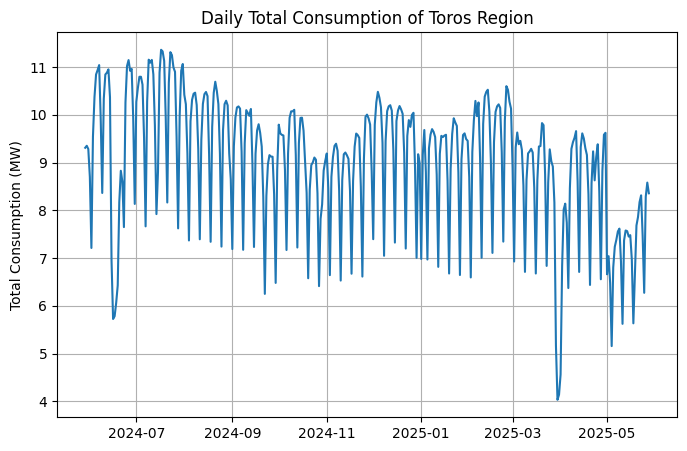

In [ ]:
# Plot using matplotlib
import matplotlib.pyplot as plt

# Here we compare the results with the model for the entire Toros Regions
df_toros_agg['TotalConsumption'] = df_toros_agg[consumption_hours].sum(axis=1) # Total consumption for all toros region

# Here we use a scale to present the data
MW = 1000000

# Plot the total consumption
plt.figure(figsize=(8, 5))
plt.plot(df_toros_agg['DATE'], df_toros_agg['TotalConsumption']/MW)

plt.ylabel('Total Consumption (MW)')
plt.title('Daily Total Consumption of Toros Region')
plt.grid(True)
plt.show()

In [ ]:
def transform_consumption_dataframe(df_agg_season, season, consumption_hours):
  """
    This function transposes and formats the consumption dataframe for a given season.
  """
  # Here we create hours for our plots
  hours = [f'{h:02d}:00' for h in range(24)]
  # Here we initialize the list to store transposed dataframes for each day type
  transposed_dfs = []

  # Filter the dataframe for the given season
  df_season_filtered = df_agg_season[df_agg_season['SEASON'] == season]

  # Iterate through unique day types for the given season
  for day_type in df_season_filtered['NEW_DAY_TYPE'].unique():
      # Filter for the current day type
      filtered_df = df_season_filtered[df_season_filtered['NEW_DAY_TYPE'] == day_type][consumption_hours].T.reset_index()
      # Rename the consumption column
      filtered_df.columns = ['Hour', day_type]
      transposed_dfs.append(filtered_df)

  # Merge the transposed dataframes on the 'Hour' column
  if transposed_dfs:
      df_season = transposed_dfs[0]
      for i in range(1, len(transposed_dfs)):
          df_season = pd.merge(df_season, transposed_dfs[i], on='Hour')
      # Here we set hours to actual hours
      df_season['Hour'] = hours
      # Set 'Hour' as the index
      df_season.set_index('Hour', inplace=True)
      return df_season
  else:
      return pd.DataFrame({'Hour': hours}) # Return a dataframe with just hours if no data

(150000.0, 600000.0)

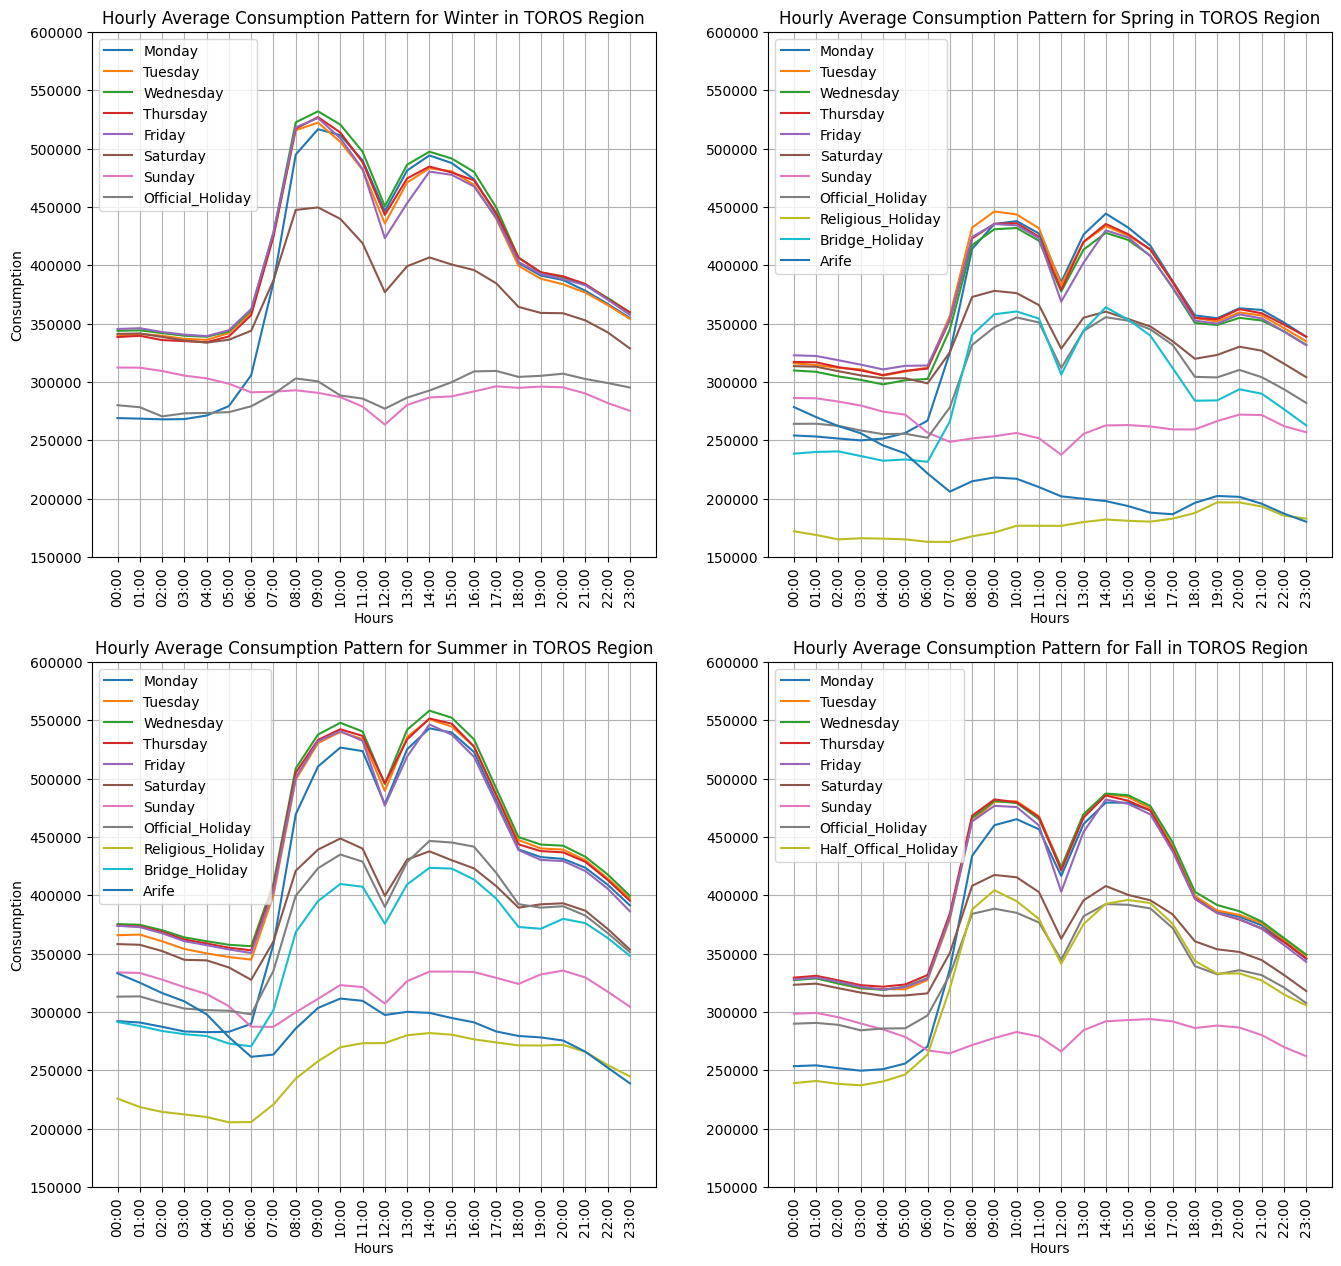

In [ ]:
# Here we create hours for our plots
hours = [f'{h:02d}:00' for h in range(24)]
# Here we aggregate data for TOROS region to check patterns for each day type and month
agg_columns = ['NEW_DAY_TYPE', 'SEASON']
# Sum consumption based on cities
df_toros_agg_season = df_toros_agg.groupby(agg_columns)[consumption_hours].mean().reset_index()
# Group into dictionary: Category → list of Items
day_type_map = df_takvim[['NEW_DAY_TYPE', 'NEW_DAY_TYPE_TXT']].drop_duplicates().groupby('NEW_DAY_TYPE')['NEW_DAY_TYPE_TXT'].apply(list).to_dict()
# Transform the data for Winter (SEASON 1)
df_winter = transform_consumption_dataframe(df_toros_agg_season, 1, consumption_hours)
# Transform the data for Spring (SEASON 2)
df_spring = transform_consumption_dataframe(df_toros_agg_season, 2, consumption_hours)
# Transform the data for Summer (SEASON 3)
df_summer = transform_consumption_dataframe(df_toros_agg_season, 3, consumption_hours)
# Transform the data for Fall (SEASON 4)
df_fall = transform_consumption_dataframe(df_toros_agg_season, 4, consumption_hours)

# Iterate through unique combinations of NEW_DAY_TYPE and SEASON
fig, axes = plt.subplots(2, 2, figsize=(16, 15))

# Plot Winter Season
for col in df_winter.columns:
  axes[0, 0].plot(df_winter.index, df_winter[col], label=day_type_map[col])
# Here we arrange the subplot axis and legends
axes[0, 0].set_title('Hourly Average Consumption Pattern for Winter in TOROS Region')
axes[0, 0].set_ylabel('Consumption')
axes[0, 0].set_xticks(range(len(hours)))
axes[0, 0].set_xticklabels(hours, rotation=90)
axes[0, 0].legend()
axes[0, 0].grid(True)
axes[0, 0].set_xlabel('Hours')
axes[0, 0].set_ylim(150000, 600000)  # Set y-axis limit

# Plot Spring Season
for col in df_spring.columns:
  axes[0, 1].plot(df_spring.index, df_spring[col], label=day_type_map[col])
# Here we arrange the subplot axis and legends
axes[0, 1].set_title('Hourly Average Consumption Pattern for Spring in TOROS Region')
axes[0, 1].set_xticks(range(len(hours)))
axes[0, 1].set_xticklabels(hours, rotation=90)
axes[0, 1].legend()
axes[0, 1].grid(True)
axes[0, 1].set_xlabel('Hours')
axes[0, 1].set_ylim(150000, 600000)  # Set y-axis limit

# Plot Summer Season
for col in df_summer.columns:
  axes[1, 0].plot(df_summer.index, df_summer[col], label=day_type_map[col])
# Here we arrange the subplot axis and legends
axes[1, 0].set_title('Hourly Average Consumption Pattern for Summer in TOROS Region')
axes[1, 0].set_ylabel('Consumption')
axes[1, 0].set_xticks(range(len(hours)))
axes[1, 0].set_xticklabels(hours, rotation=90)
axes[1, 0].legend()
axes[1, 0].grid(True)
axes[1, 0].set_xlabel('Hours')
axes[1, 0].set_ylim(150000, 600000)  # Set y-axis limit

# Plot Fall Season
for col in df_fall.columns:
  axes[1, 1].plot(df_summer.index, df_fall[col], label=day_type_map[col])
# Here we arrange the subplot axis and legends
axes[1, 1].set_title('Hourly Average Consumption Pattern for Fall in TOROS Region')
axes[1, 1].set_xticks(range(len(hours)))
axes[1, 1].set_xticklabels(hours, rotation=90)
axes[1, 1].legend()
axes[1, 1].grid(True)
axes[1, 1].set_xlabel('Hours')
axes[1, 1].set_ylim(150000, 600000)  # Set y-axis limit

#3. Machine Learning Models and Features


1.   Linear Regression
2.   Random Forrest Regressor
3.   Gradient Boosting Model



In [ ]:
# Here we organize the meteorological data to feed our model
# Temperature difference between the actual temperature and the comfort temperature will have an impact on
# the air conditioning so does the electricity consumption
df_meteo['Temp_Diff'] = df_meteo['AirTemperature'] - df_meteo['ComfortTemperature']
# The precipitation height is likely to have an impact on the electricity consumption so fill with 0 for the missing data
df_meteo['Precipitationheight'].fillna(0, inplace=True)
# Here we drop the columns, which we can't see a direct impact
df_meteo['Location'] = df_meteo['Location'].str.replace(r'[^A-Za-z]', '', regex=True)

# Replace 'IstanbulAsia' with 'Istanbulasia'
df_meteo['Location'] = df_meteo['Location'].replace('IstanbulAsia', 'Istanbulasia')
# Replace 'IstanbulEurope' with 'Istanbuleurope'
df_meteo['Location'] = df_meteo['Location'].replace('IstanbulEurope', 'Istanbuleurope')
# Here we aggregate data for date and city
agg_columns = ['Date',  'Location']
# Here we list the columns where we take the average
feature_columns = ['RelativeHumidity',  'WindSpeed',
                   'EffectiveCloudCover',    'Precipitationheight','Temp_Diff']
# Mean weather conditions based on cities and date
df_meteo_daily = df_meteo.groupby(agg_columns)[feature_columns].mean().reset_index()

# Convert 'Date' column in df_meteo_daily to datetime objects
df_meteo_daily['Date'] = pd.to_datetime(df_meteo_daily['Date'], format='%d.%m.%Y')

print("Total Rows in Daily Meteorology Data",len(df_meteo_daily))

print(df_meteo_daily.dtypes)
df_meteo_daily.head()

/tmp/ipython-input-21-3624121381.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_meteo['Precipitationheight'].fillna(0, inplace=True)


Total Rows in Daily Meteorology Data 3032
Date                   datetime64[ns]
Location                       object
RelativeHumidity              float64
WindSpeed                     float64
EffectiveCloudCover           float64
Precipitationheight           float64
Temp_Diff                     float64
dtype: object


,Date,Location,RelativeHumidity,WindSpeed,EffectiveCloudCover,Precipitationheight,Temp_Diff
0,2025-01-01,Adana,57.366667,1.716667,0.00,0.0,0.987500
1,2025-01-01,Ankara,72.537500,0.437500,0.00,0.0,0.216667
2,2025-01-01,Gaziantep,64.941667,2.112500,0.00,0.0,1.029167
3,2025-01-01,Hatay,83.016667,0.462500,3.45,0.0,0.208333
4,2025-01-01,Istanbulasia,78.233333,0.270833,0.00,0.0,0.270833


In [ ]:
# Here we merge the weather and the electricity consumption data on city and date

# Here we aggregate the electricity consumption for each city
try:
  df_train_agg['TotalConsumption'] = df_train_agg[consumption_hours].sum(axis=1)
  df_train_agg.drop(consumption_hours, axis=1, inplace=True)
except:
  pass

# Here we strip Sehir to only letters in df_train_agg data
try:
  df_train_agg['Sehir'] = df_train_agg['Sehir'].str.replace(r'[^A-Za-z]', '', regex=True)
except:
  pass

# Here we merge the weather and the electricity consumption data
df_train_weather_agg = pd.merge(df_train_agg, df_meteo_daily, left_on=['DATE', 'Sehir'], right_on=['Date', 'Location'], how='left')
# Here we drop the duplicate columns
df_train_weather_agg.drop(['Date', 'Location'], axis=1, inplace=True)

df_train_weather_agg.head(60)

,DATE,OFFICIAL_HOLIDAY,RELIGIOUS_HOLIDAY,Weekday_N,Weekend_N,NEW_DAY_TYPE,NEW_DAY_TYPE_TXT,ACTUAL_HOLIDAYS,BOLGE,Sehir,TotalConsumption,RelativeHumidity,WindSpeed,EffectiveCloudCover,Precipitationheight,Temp_Diff
0,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Adana,2.479789e+06,76.295833,2.675000,3.083333,0.004167,-4.966667
1,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Amasya,3.958920e+04,NaN,NaN,NaN,NaN,NaN
2,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Ankara,1.305383e+04,67.066667,0.712500,2.491667,0.000000,-0.562500
3,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Antalya,6.547408e+05,NaN,NaN,NaN,NaN,NaN
4,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Bingol,9.240000e+01,NaN,NaN,NaN,NaN,NaN
5,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Bitlis,3.137280e+02,NaN,NaN,NaN,NaN,NaN
6,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Bursa,3.355200e+02,NaN,NaN,NaN,NaN,NaN
7,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Cankiri,2.621500e+02,NaN,NaN,NaN,NaN,NaN
8,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Diyarbakir,6.277526e+03,NaN,NaN,NaN,NaN,NaN
9,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Edirne,4.144200e+02,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Here we count the missing data for the aggreageted training data
missing_train = df_train_weather_agg.isnull().sum()
print(missing_train)
print("Total Rows in Aggregated Training Data",len(df_train_agg))

DATE                       0
OFFICIAL_HOLIDAY           0
RELIGIOUS_HOLIDAY          0
Weekday_N                  0
Weekend_N                  0
NEW_DAY_TYPE               0
NEW_DAY_TYPE_TXT           0
ACTUAL_HOLIDAYS            0
BOLGE                      0
Sehir                      0
TotalConsumption           0
RelativeHumidity       11888
WindSpeed              11888
EffectiveCloudCover    11888
Precipitationheight    11888
Temp_Diff              11888
dtype: int64
Total Rows in Aggregated Training Data 14808


#3.1 Data Imputation for Geospatial Data

In [ ]:
# Here we import relevant libraries for Geospatial Data Analysis
from geopy.geocoders import Nominatim
import geopandas as gpd
import time

# Sehirler
cities = df_train_agg['Sehir'].unique().tolist()

# Geocode each city to get lat/lon
geolocator = Nominatim(user_agent="city_mapper", timeout=10) # Increased timeout to 10 seconds
locations = []

for city in cities:
    try:
        location = geolocator.geocode(city + ", Turkey")
        if location:
            locations.append({'City': city, 'Latitude': location.latitude, 'Longitude': location.longitude})
        time.sleep(1) # Add a small delay between requests
    except Exception as e:
        print(f"Error geocoding {city}: {e}")
        time.sleep(5) # Add a longer delay if an error occurs to avoid further issues


df_geo = pd.DataFrame(locations)

In [ ]:
# Here we aggregate data for date and city
agg_columns = ['Location']
# Here we list the columns where we take the average
feature_columns = ['RelativeHumidity',  'WindSpeed',
                   'EffectiveCloudCover',    'Precipitationheight', 'Temp_Diff']
# Mean weather conditions for each city
df_meteo_city = df_meteo_daily.groupby(agg_columns)[feature_columns].mean().reset_index()

df_meteo_city.head(10)

,Location,RelativeHumidity,WindSpeed,EffectiveCloudCover,Precipitationheight,Temp_Diff
0,Adana,63.252639,2.529354,1.815084,0.047999,-3.496086
1,Ankara,56.024351,1.459543,2.756926,0.045690,-0.023450
2,Gaziantep,49.908619,2.997570,1.412698,0.025352,-0.110290
3,Hatay,61.780123,4.595822,1.740963,0.025737,-2.779815
4,Istanbulasia,67.466524,0.649307,2.704178,0.068085,-2.023131
5,Istanbuleurope,69.019888,4.585928,2.609334,0.057751,-1.453540
6,Mersin,62.752364,1.117568,1.989974,0.048219,-4.245888
7,Zonguldak,74.926968,2.195207,3.047669,0.147636,-1.707289


In [ ]:
# Here we merge the weather and the electricity consumption data
df_meteo_city = pd.merge(df_geo, df_meteo_city, left_on=['City'], right_on=['Location'], how='left')
# Here we drop duplicate columns
df_meteo_city.drop(['Location'], axis=1, inplace=True)
df_meteo_city.dropna(inplace=True)
df_meteo_city.head(20)

,City,Latitude,Longitude,RelativeHumidity,WindSpeed,EffectiveCloudCover,Precipitationheight,Temp_Diff
0,Adana,36.986360,35.325286,63.252639,2.529354,1.815084,0.047999,-3.496086
2,Ankara,39.920776,32.854050,56.024351,1.459543,2.756926,0.045690,-0.023450
12,Gaziantep,37.062832,37.379262,49.908619,2.997570,1.412698,0.025352,-0.110290
13,Hatay,36.345133,36.074802,61.780123,4.595822,1.740963,0.025737,-2.779815
24,Mersin,36.797838,34.629839,62.752364,1.117568,1.989974,0.048219,-4.245888
31,Zonguldak,41.250324,31.838974,74.926968,2.195207,3.047669,0.147636,-1.707289


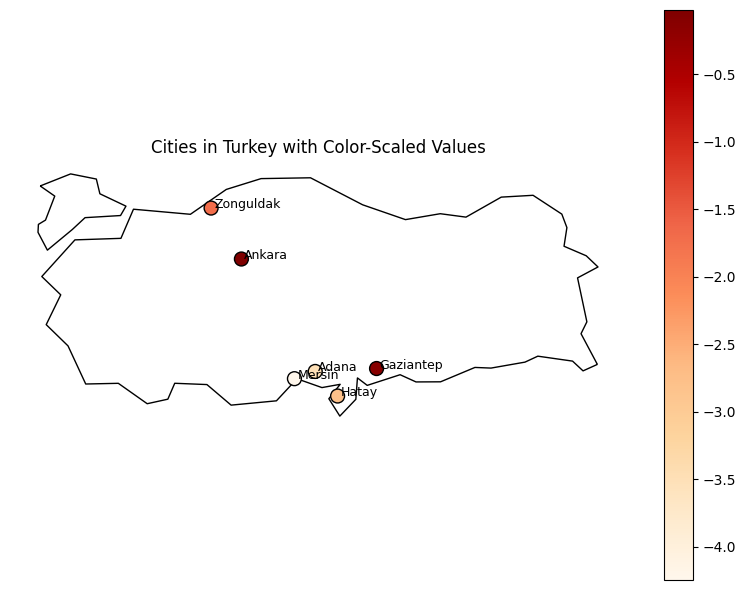

In [ ]:
# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_meteo_city,
    geometry=gpd.points_from_xy(df_meteo_city['Longitude'], df_meteo_city['Latitude']),
    crs="EPSG:4326"
)

# Load world map from GeoJSON
world = gpd.read_file("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson")

# Filter the world map to only show Turkey (optional)
turkey = world[world['NAME'] == 'Turkey']

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot Turkey borders
turkey.plot(ax=ax, color='white', edgecolor='black')

# Plot cities with color scaling based on 'Value'
gdf.plot(
    ax=ax,
    column='Temp_Diff',
    cmap='OrRd',
    legend=True,
    markersize=100,
    edgecolor='black'
)

# Label the cities
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf['City']):
    ax.text(x + 0.1, y, label, fontsize=9)

plt.title("Cities in Turkey with Color-Scaled Values")
plt.axis('off')
plt.tight_layout()
plt.show()

#3.2 Models for both cities with weather data and cities without weather data

In [ ]:
# Here we load libraries to fit and transform month and Day Type
from sklearn.preprocessing import OneHotEncoder

# Extract numeric month
df_train_weather_agg['MONTH'] = df_train_weather_agg['DATE'].dt.month

# Extract day of the year
df_train_weather_agg['DayOfYear'] = df_train_weather_agg['DATE'].dt.dayofyear

# Initialize the One Hot Encoder
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the 'NEW_DAY_TYPE' column
encoded_days = encoder.fit_transform(df_train_weather_agg[['NEW_DAY_TYPE']])

# Get column names from encoder
encoded_cols = encoder.get_feature_names_out(['NEW_DAY_TYPE'])

# Create DataFrame of encoded columns
df_encoded = pd.DataFrame(encoded_days, columns=encoded_cols, index=df_train_weather_agg.index)

# Here we merge the encoded days
df_train_weather_agg = pd.concat([df_train_weather_agg, df_encoded], axis=1)

df_train_weather_agg.head()

,DATE,OFFICIAL_HOLIDAY,RELIGIOUS_HOLIDAY,Weekday_N,Weekend_N,NEW_DAY_TYPE,NEW_DAY_TYPE_TXT,ACTUAL_HOLIDAYS,BOLGE,Sehir,...,NEW_DAY_TYPE_3,NEW_DAY_TYPE_4,NEW_DAY_TYPE_5,NEW_DAY_TYPE_6,NEW_DAY_TYPE_7,NEW_DAY_TYPE_8,NEW_DAY_TYPE_9,NEW_DAY_TYPE_10,NEW_DAY_TYPE_11,NEW_DAY_TYPE_12
0,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Adana,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Amasya,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Ankara,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Antalya,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-05-29,0,0,1,0,3,Wednesday,0,TOROSLAR,Bingol,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Fit and transform the 'MONTH' column
encoded_months = encoder.fit_transform(df_train_weather_agg[['MONTH']])

# Get column names from encoder
encoded_cols = encoder.get_feature_names_out(['MONTH'])

# Create DataFrame of encoded columns
df_encoded = pd.DataFrame(encoded_days, columns=encoded_cols, index=df_train_weather_agg.index)

# Here we merge the encoded days
df_train_weather_agg = pd.concat([df_train_weather_agg, df_encoded], axis=1)

# Here we drop unused columns for the model
df_train_weather_agg_red = df_train_weather_agg.drop(['OFFICIAL_HOLIDAY', 'RELIGIOUS_HOLIDAY',
                                                      'Weekday_N', 'Weekend_N', 'NEW_DAY_TYPE', 'NEW_DAY_TYPE_TXT',
                                                      'ACTUAL_HOLIDAYS', 'BOLGE', 'MONTH'], axis=1)

df_train_weather_agg_red.head()

,DATE,Sehir,TotalConsumption,RelativeHumidity,WindSpeed,EffectiveCloudCover,Precipitationheight,Temp_Diff,DayOfYear,NEW_DAY_TYPE_1,...,MONTH_3,MONTH_4,MONTH_5,MONTH_6,MONTH_7,MONTH_8,MONTH_9,MONTH_10,MONTH_11,MONTH_12
0,2024-05-29,Adana,2.479789e+06,76.295833,2.6750,3.083333,0.004167,-4.966667,150,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-05-29,Amasya,3.958920e+04,NaN,NaN,NaN,NaN,NaN,150,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-05-29,Ankara,1.305383e+04,67.066667,0.7125,2.491667,0.000000,-0.562500,150,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-05-29,Antalya,6.547408e+05,NaN,NaN,NaN,NaN,NaN,150,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-05-29,Bingol,9.240000e+01,NaN,NaN,NaN,NaN,NaN,150,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def linear_regression_model(df):

  """
    This function generates a linear regression model for each city
  """

  # First we drop NA for the cities we miss the weather data
  df = df.dropna(axis=1)

  # Here we split the data into features
  X = df.drop(columns=['DATE', 'TotalConsumption',
                       'Sehir'])         # Features
  y = df['TotalConsumption']             # Target

  # Here we split the data into training and the test data to check the accuracy
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  # Here we initialize and fit the model
  model = LinearRegression()
  model.fit(X_train, y_train)

  # Here we make a prediction check the accuracy
  y_pred = model.predict(X_test)

  #print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
  #print("R-squared Score:", r2_score(y_test, y_pred))

  return model, r2_score(y_test, y_pred)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def random_forrest_regressor_model(df):

  """
    This function generates a Random Forrest Regressor model for each city
  """

  # First we drop NA for the cities we miss the weather data
  df = df.dropna(axis=1)

  # Here we split the data into features
  X = df.drop(columns=['DATE', 'TotalConsumption',
                       'Sehir'])         # Features
  y = df['TotalConsumption']             # Target

  # Here we split the data into training and the test data to check the accuracy
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  # Here we initialize and fit the model
  model =  RandomForestRegressor(n_estimators=100, random_state=42)
  model.fit(X_train, y_train)

  # Here we make a prediction check the accuracy
  y_pred = model.predict(X_test)

  #print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
  #print("R-squared Score:", r2_score(y_test, y_pred))

  return model, r2_score(y_test, y_pred)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def gradient_boosting_regressor_model(df):

  """
    This function generates a Gradient Boosting Regressor model for each city
  """

  # First we drop NA for the cities we miss the weather data
  df = df.dropna(axis=1)

  # Here we split the data into features
  X = df.drop(columns=['DATE', 'TotalConsumption',
                       'Sehir'])         # Features
  y = df['TotalConsumption']             # Target

  # Here we split the data into training and the test data to check the accuracy
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  # Here we initialize and fit the model
  model =  GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
  model.fit(X_train, y_train)

  # Here we make a prediction check the accuracy
  y_pred = model.predict(X_test)

  #print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
  #print("R-squared Score:", r2_score(y_test, y_pred))

  return model, r2_score(y_test, y_pred)

In [ ]:
# Initialize an empty dictionary to store the Linear Regression models
lr_models = {}
# Initialize an empty dictionary to store R^2 values of the Linear Regression model
lr_R2 = {}

for city in df_train_weather_agg_red['Sehir'].unique():
  # Here we return a corresponding Random Forrest Regressor model for each city
  df_city = df_train_weather_agg_red[df_train_weather_agg_red['Sehir'] == city]
  model, R2 = linear_regression_model(df_city)
  # Here we store the model
  lr_models[city] = model
  # Here we store the R^2 value
  lr_R2[city] = R2

print(lr_R2)

{'Adana': 0.8002357602125795, 'Amasya': 0.0685791493514668, 'Ankara': 0.49601532491979927, 'Antalya': -0.18804196859347133, 'Bingol': 0.6415072705788039, 'Bitlis': 0.08959721073517257, 'Bursa': 0.0881215031695256, 'Cankiri': -0.0600546899612886, 'Diyarbakir': 0.285453270541552, 'Edirne': -0.1182731494038638, 'Elazig': 0.15030794322955032, 'Erzurum': -0.14524842534596738, 'Gaziantep': 0.4269537311180803, 'Hatay': 0.7709511971930961, 'Isparta': -0.061880169125994255, 'Istanbulasia': 0.7491277894997364, 'Istanbuleurope': 0.5306909532586462, 'Izmir': 0.18211212227350881, 'Kahramanmaras': 0.11725930607851998, 'Karaman': -0.09734827933049739, 'Kayseri': 0.044472987116588536, 'Kilis': 0.27397922935170127, 'Kocaeli': 0.3289676540430694, 'Konya': 0.5378799793709512, 'Manisa': 0.011360496829780797, 'Mardin': 0.2949662288860688, 'Mersin': 0.8443396777209005, 'Mugla': -0.061867608488406, 'Nevsehir': 0.006099917095988339, 'Nigde': 0.010930227117945557, 'Osmaniye': 0.35100528725021274, 'Sakarya': 0.

In [ ]:
# Initialize an empty dictionary to store the Random Forrest Regressor models
rf_models = {}
# Initialize an empty dictionary to store R^2 values of the Random Forrest Regressor model
rf_R2 = {}

for city in df_train_weather_agg_red['Sehir'].unique():
  # Here we return a corresponding Random Forrest Regressor model for each city
  df_city = df_train_weather_agg_red[df_train_weather_agg_red['Sehir'] == city]
  model, R2 = random_forrest_regressor_model(df_city)
  # Here we store the model
  rf_models[city] = model
  # Here we store the R^2 value
  rf_R2[city] = R2

print(rf_R2)

{'Adana': 0.8530048722194905, 'Amasya': 0.6673360730310702, 'Ankara': 0.7772289386751645, 'Antalya': 0.8929561478338566, 'Bingol': 0.9906303374794133, 'Bitlis': 0.993842207272205, 'Bursa': 0.9846016507997168, 'Cankiri': 0.9765426137398031, 'Diyarbakir': 0.572141388179026, 'Edirne': 0.6646622654725922, 'Elazig': 0.9224301206182132, 'Erzurum': 0.8092687348598768, 'Gaziantep': 0.8151842168185478, 'Hatay': 0.8480840745617665, 'Isparta': 0.5042739650384076, 'Istanbulasia': 0.8726131295591757, 'Istanbuleurope': 0.797688669399204, 'Izmir': 0.9294069474368236, 'Kahramanmaras': 0.4478291094687631, 'Karaman': 0.34560387105537305, 'Kayseri': 0.8478686219395225, 'Kilis': 0.8932029240473842, 'Kocaeli': 0.6416860181283295, 'Konya': 0.6988082051153147, 'Manisa': 0.9588902456138988, 'Mardin': 0.3295288838175181, 'Mersin': 0.8419160800474392, 'Mugla': 0.9909953429847074, 'Nevsehir': 0.8201914821852303, 'Nigde': 0.8785917561456837, 'Osmaniye': 0.7757673969257057, 'Sakarya': 0.8192864162609371, 'Sanliurf

In [ ]:
# Initialize an empty dictionary to store the Gradient Boosting Regressor models
gb_models = {}
# Initialize an empty dictionary to store R^2 values of the Gradient Boosting Regressor model
gb_R2 = {}

for city in df_train_weather_agg_red['Sehir'].unique():
  # Here we return a corresponding Gradient Boosting Regressor model for each city
  df_city = df_train_weather_agg_red[df_train_weather_agg_red['Sehir'] == city]
  model, R2 = gradient_boosting_regressor_model(df_city)
  # Here we store the model
  gb_models[city] = model
  # Here we store the R^2 value
  gb_R2[city] = R2

print(rf_R2)

{'Adana': 0.8530048722194905, 'Amasya': 0.6673360730310702, 'Ankara': 0.7772289386751645, 'Antalya': 0.8929561478338566, 'Bingol': 0.9906303374794133, 'Bitlis': 0.993842207272205, 'Bursa': 0.9846016507997168, 'Cankiri': 0.9765426137398031, 'Diyarbakir': 0.572141388179026, 'Edirne': 0.6646622654725922, 'Elazig': 0.9224301206182132, 'Erzurum': 0.8092687348598768, 'Gaziantep': 0.8151842168185478, 'Hatay': 0.8480840745617665, 'Isparta': 0.5042739650384076, 'Istanbulasia': 0.8726131295591757, 'Istanbuleurope': 0.797688669399204, 'Izmir': 0.9294069474368236, 'Kahramanmaras': 0.4478291094687631, 'Karaman': 0.34560387105537305, 'Kayseri': 0.8478686219395225, 'Kilis': 0.8932029240473842, 'Kocaeli': 0.6416860181283295, 'Konya': 0.6988082051153147, 'Manisa': 0.9588902456138988, 'Mardin': 0.3295288838175181, 'Mersin': 0.8419160800474392, 'Mugla': 0.9909953429847074, 'Nevsehir': 0.8201914821852303, 'Nigde': 0.8785917561456837, 'Osmaniye': 0.7757673969257057, 'Sakarya': 0.8192864162609371, 'Sanliurf

In [ ]:
print("Total Rows in Aggregated Training Data",len(df_train_weather_agg_red[df_train_weather_agg_red['Sehir'] == 'Giresun']))
df_train_weather_agg_red[df_train_weather_agg_red['Sehir'] == 'Giresun']

Total Rows in Aggregated Training Data 30


,DATE,Sehir,TotalConsumption,RelativeHumidity,WindSpeed,EffectiveCloudCover,Precipitationheight,Temp_Diff,DayOfYear,NEW_DAY_TYPE_1,...,MONTH_3,MONTH_4,MONTH_5,MONTH_6,MONTH_7,MONTH_8,MONTH_9,MONTH_10,MONTH_11,MONTH_12
12522,2025-04-01,Giresun,121.8134,NaN,NaN,NaN,NaN,NaN,91,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
12567,2025-04-02,Giresun,118.3934,NaN,NaN,NaN,NaN,NaN,92,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12612,2025-04-03,Giresun,123.8484,NaN,NaN,NaN,NaN,NaN,93,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12657,2025-04-04,Giresun,118.5604,NaN,NaN,NaN,NaN,NaN,94,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12702,2025-04-05,Giresun,128.6666,NaN,NaN,NaN,NaN,NaN,95,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
12747,2025-04-06,Giresun,119.1304,NaN,NaN,NaN,NaN,NaN,96,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
12792,2025-04-07,Giresun,118.1124,NaN,NaN,NaN,NaN,NaN,97,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12837,2025-04-08,Giresun,121.8135,NaN,NaN,NaN,NaN,NaN,98,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12882,2025-04-09,Giresun,113.4973,NaN,NaN,NaN,NaN,NaN,99,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12927,2025-04-10,Giresun,111.5873,NaN,NaN,NaN,NaN,NaN,100,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Here we remove Giresun from all models and Dataframes
df_train_weather_agg_red = df_train_weather_agg_red[df_train_weather_agg_red['Sehir'] != 'Giresun']
# Here we remove it from models
lr_models.pop('Giresun')
rf_models.pop('Giresun')
gb_models.pop('Giresun')
# Here we remove it from all R^2 outputs
lr_R2.pop('Giresun')
rf_R2.pop('Giresun')
gb_R2.pop('Giresun')

-25.54589758694901

In [ ]:
# Here we calculate the average R^2 values for Random Forrest and Gradient Boosting
average_rf = sum(rf_R2.values()) / len(rf_R2)
average_gb = sum(gb_R2.values()) / len(gb_R2)

print("Average R^2 for Random Forrest Regressor:", average_rf)
print("Average R^2 for Gradient Boosting Regressor:", average_gb)

Average R^2 for Random Forrest Regressor: 0.7816776553703234
Average R^2 for Gradient Boosting Regressor: 0.7929424823859094


In [ ]:
df_Adana = df_train_weather_agg_red[df_train_weather_agg_red['Sehir'] == 'Adana']

gb_model_Adana, gb_r2_Adana = gradient_boosting_regressor_model(df_Adana)

print(gb_model_Adana.feature_importances_)

[0.0044259  0.0066252  0.0041422  0.0053932  0.25125081 0.13429056
 0.0034243  0.00184181 0.00055435 0.00266135 0.00210305 0.02049576
 0.10315619 0.00536836 0.0837096  0.00048448 0.00456832 0.
 0.002578   0.00330732 0.00275129 0.00213371 0.00043309 0.01055309
 0.23614059 0.00529321 0.09651499 0.00062502 0.00517428 0.        ]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_feature_importance(model, df, top_n=21):
    """
    Plot the top N feature importances of a trained RandomForestRegressor model.

    Parameters:
        model: trained RandomForestRegressor object
        df: dataframe used in training (should contain same feature columns)
        top_n: number of top features to display
    """

    # Feature names (excluding target and non-feature columns)
    feature_names = df.drop(columns=['DATE', 'TotalConsumption', 'Sehir']).columns

    # Feature importances from the model
    importances = model.feature_importances_

    # DataFrame with features and their importances
    feat_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).head(top_n)

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top {top_n} Feature Importances (Gradient Boosting)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

/tmp/ipython-input-70-257174313.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')


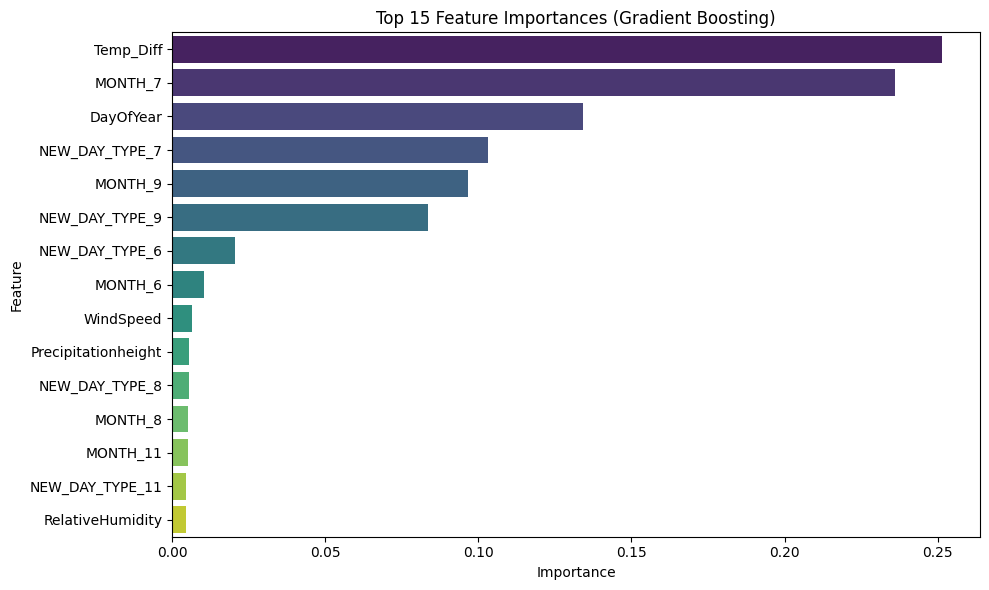

In [ ]:
plot_feature_importance(gb_model_Adana, df_Adana, top_n=15)

#4. Model Results

In [ ]:
# Here we fit the results for each city and compare it with the actual data

# The data for the cities with the weather data
df_city_w_weather = df_train_weather_agg_red.dropna()

# Here we create an empty dataframe to store the model results
df_model_w_weather = pd.DataFrame()
df_model_w_weather['DATE'] = df_city_w_weather['DATE'].unique()

# Here we forecast the consumption for cities with the weather data
for city in df_city_w_weather['Sehir'].unique():
  # Here we separate inputs for each city
  df_city = df_city_w_weather[df_city_w_weather['Sehir'] == city]
  X_test = df_city.drop(columns=['DATE', 'TotalConsumption','Sehir'])         # Features
  # Here we fit the model
  df_model_w_weather[city] = gb_models[city].predict(X_test)

df_model_w_weather.head()

,DATE,Adana,Ankara,Gaziantep,Hatay,Istanbulasia,Istanbuleurope,Mersin,Zonguldak
0,2024-05-29,2.609919e+06,13374.278836,2.182314e+06,1.037638e+06,16120.209304,6361.727057,1.541598e+06,168.289447
1,2024-05-30,2.574423e+06,13482.557716,2.210124e+06,1.057897e+06,16804.769699,6701.410540,1.469444e+06,156.082150
2,2024-05-31,2.526717e+06,13267.728062,2.217036e+06,1.041476e+06,16700.044922,5755.020751,1.456690e+06,157.207850
3,2024-06-01,2.533335e+06,10071.906982,2.005692e+06,9.907837e+05,16671.764903,5618.991652,1.410621e+06,148.957048
4,2024-06-02,2.006112e+06,9187.877766,1.653788e+06,7.114128e+05,15196.880685,4462.182959,1.095360e+06,145.477476


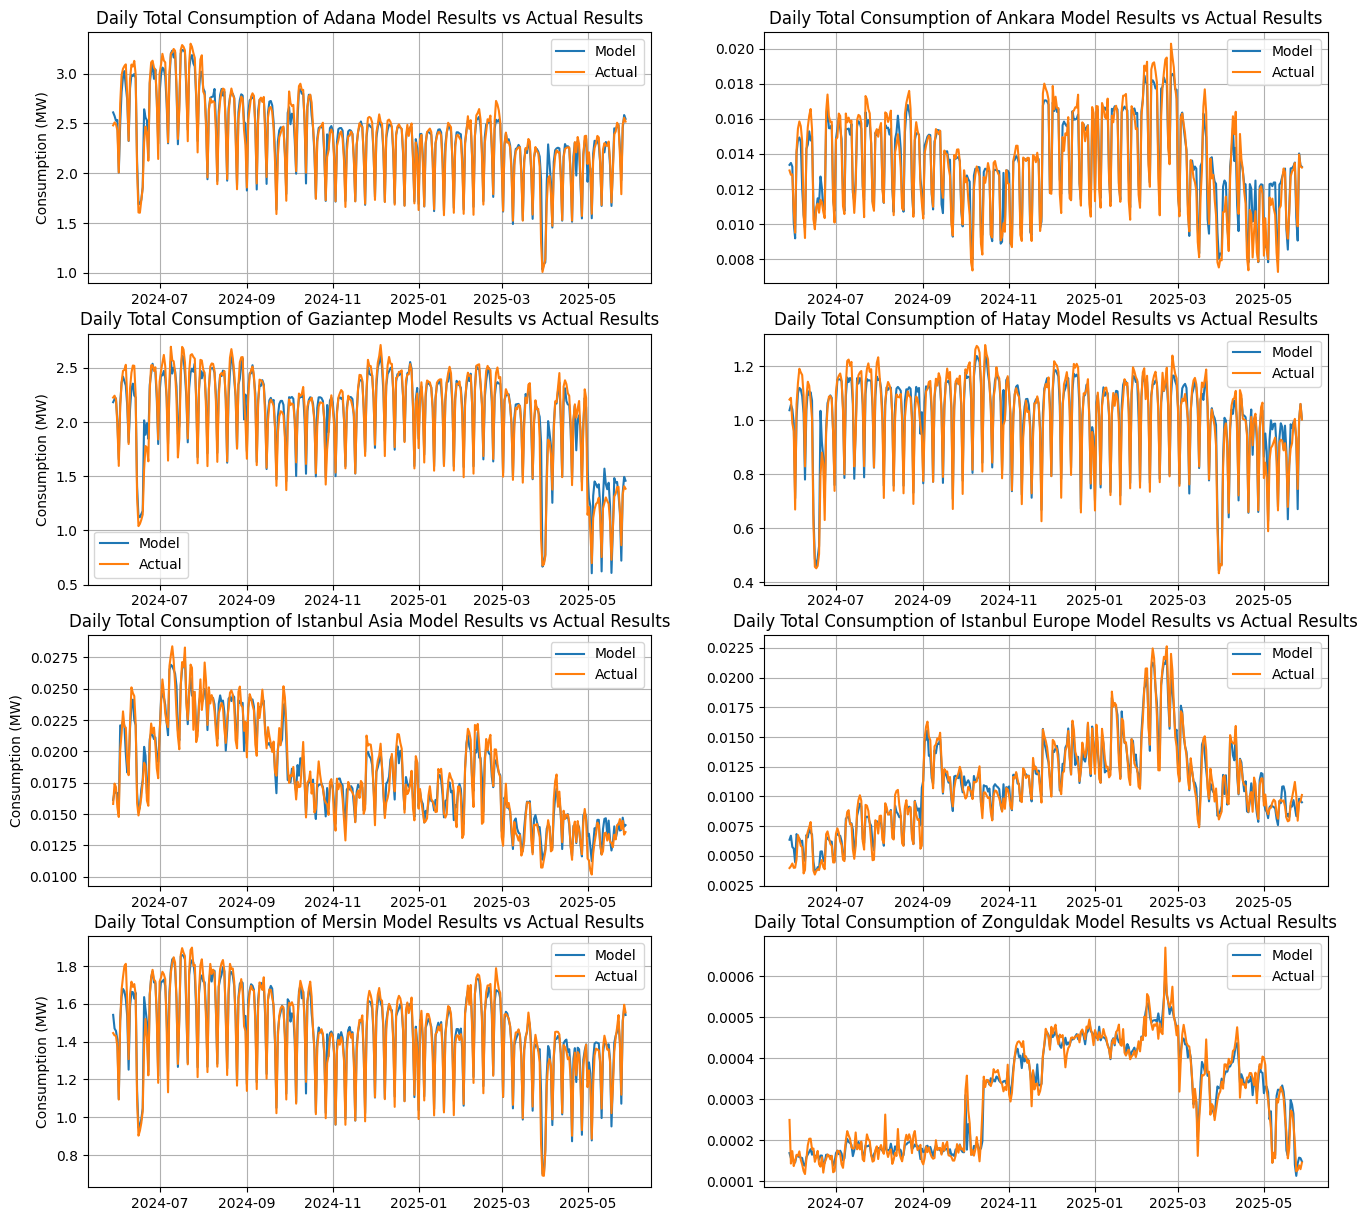

In [ ]:
# Here we normalize with Mega Watt
MW = 1000000

# Here we compare the model result with the actual data for the cities with the weather data
fig, axes = plt.subplots(4, 2, figsize=(16, 15))

# Plot Adana Model Results
axes[0, 0].plot(df_model_w_weather['DATE'],
                df_model_w_weather['Adana']/MW, label='Model')
axes[0, 0].plot(df_city_w_weather[df_city_w_weather['Sehir'] == 'Adana']['DATE'],
                df_city_w_weather[df_city_w_weather['Sehir'] == 'Adana']['TotalConsumption']/MW, label='Actual')
# Here we arrange the subplot axis and legends
axes[0, 0].set_title('Daily Total Consumption of Adana Model Results vs Actual Results')
axes[0, 0].set_ylabel('Consumption (MW)')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot Ankara Model Results
axes[0, 1].plot(df_model_w_weather['DATE'],
                df_model_w_weather['Ankara']/MW, label='Model')
axes[0, 1].plot(df_city_w_weather[df_city_w_weather['Sehir'] == 'Ankara']['DATE'],
                df_city_w_weather[df_city_w_weather['Sehir'] == 'Ankara']['TotalConsumption']/MW, label='Actual')
# Here we arrange the subplot axis and legends
axes[0, 1].set_title('Daily Total Consumption of Ankara Model Results vs Actual Results')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot Gaziantep Model Results
axes[1, 0].plot(df_model_w_weather['DATE'],
                df_model_w_weather['Gaziantep']/MW, label='Model')
axes[1, 0].plot(df_city_w_weather[df_city_w_weather['Sehir'] == 'Gaziantep']['DATE'],
                df_city_w_weather[df_city_w_weather['Sehir'] == 'Gaziantep']['TotalConsumption']/MW, label='Actual')
# Here we arrange the subplot axis and legends
axes[1, 0].set_title('Daily Total Consumption of Gaziantep Model Results vs Actual Results')
axes[1, 0].set_ylabel('Consumption (MW)')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Plot Hatay Model Results
axes[1, 1].plot(df_model_w_weather['DATE'],
                df_model_w_weather['Hatay']/MW, label='Model')
axes[1, 1].plot(df_city_w_weather[df_city_w_weather['Sehir'] == 'Hatay']['DATE'],
                df_city_w_weather[df_city_w_weather['Sehir'] == 'Hatay']['TotalConsumption']/MW, label='Actual')
# Here we arrange the subplot axis and legends
axes[1, 1].set_title('Daily Total Consumption of Hatay Model Results vs Actual Results')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Plot Istanbulasia Model Results
axes[2, 0].plot(df_model_w_weather['DATE'],
                df_model_w_weather['Istanbulasia']/MW, label='Model')
axes[2, 0].plot(df_city_w_weather[df_city_w_weather['Sehir'] == 'Istanbulasia']['DATE'],
                df_city_w_weather[df_city_w_weather['Sehir'] == 'Istanbulasia']['TotalConsumption']/MW, label='Actual')
# Here we arrange the subplot axis and legends
axes[2, 0].set_title('Daily Total Consumption of Istanbul Asia Model Results vs Actual Results')
axes[2, 0].set_ylabel('Consumption (MW)')
axes[2, 0].legend()
axes[2, 0].grid(True)

# Plot Istanbuleurope	 Model Results
axes[2, 1].plot(df_model_w_weather['DATE'],
                df_model_w_weather['Istanbuleurope']/MW, label='Model')
axes[2, 1].plot(df_city_w_weather[df_city_w_weather['Sehir'] == 'Istanbuleurope']['DATE'],
                df_city_w_weather[df_city_w_weather['Sehir'] == 'Istanbuleurope']['TotalConsumption']/MW, label='Actual')
# Here we arrange the subplot axis and legends
axes[2, 1].set_title('Daily Total Consumption of Istanbul Europe Model Results vs Actual Results')
axes[2, 1].legend()
axes[2, 1].grid(True)

# Plot Mersin Model Results
axes[3, 0].plot(df_model_w_weather['DATE'],
                df_model_w_weather['Mersin']/MW, label='Model')
axes[3, 0].plot(df_city_w_weather[df_city_w_weather['Sehir'] == 'Mersin']['DATE'],
                df_city_w_weather[df_city_w_weather['Sehir'] == 'Mersin']['TotalConsumption']/MW, label='Actual')
# Here we arrange the subplot axis and legends
axes[3, 0].set_title('Daily Total Consumption of Mersin Model Results vs Actual Results')
axes[3, 0].set_ylabel('Consumption (MW)')
axes[3, 0].legend()
axes[3, 0].grid(True)

# Plot Zonguldak Model Results
axes[3, 1].plot(df_model_w_weather['DATE'],
                df_model_w_weather['Zonguldak']/MW, label='Model')
axes[3, 1].plot(df_city_w_weather[df_city_w_weather['Sehir'] == 'Zonguldak']['DATE'],
                df_city_w_weather[df_city_w_weather['Sehir'] == 'Zonguldak']['TotalConsumption']/MW, label='Actual')
# Here we arrange the subplot axis and legends
axes[3, 1].set_title('Daily Total Consumption of Zonguldak Model Results vs Actual Results')
axes[3, 1].legend()
axes[3, 1].grid(True)

In [ ]:
# Here we fit the results for each city and compare it with the actual data

# List of cities with weather data
list_of_weather = df_city_w_weather['Sehir'].unique().tolist()
# The data for the cities without the weather data
df_city_wo_weather = df_train_weather_agg_red[~df_train_weather_agg_red['Sehir'].isin(list_of_weather)].copy()
# Here we drop the empty weather columns
df_city_wo_weather = df_city_wo_weather.dropna(axis=1)

# Here we create an empty dataframe to store the model results
df_model_wo_weather = pd.DataFrame()
df_model_wo_weather['DATE'] = df_city_wo_weather['DATE'].unique()

# Here we forecast the consumption for cities without the weather data
for city in df_city_wo_weather['Sehir'].unique():
  # Here we separate inputs for each city
  df_city = df_city_wo_weather[df_city_wo_weather['Sehir'] == city]
  X_test = df_city.drop(columns=['DATE', 'TotalConsumption','Sehir'])         # Features
  # Here we fit the model
  predictions = gb_models[city].predict(X_test)

  # Create a temporary DataFrame for predictions with dates
  df_predictions = pd.DataFrame({'DATE': df_city['DATE'], city: predictions})

  # Merge predictions with the main results DataFrame
  if df_model_wo_weather.empty:
      df_model_wo_weather = df_predictions
  else:
      df_model_wo_weather = pd.merge(df_model_wo_weather, df_predictions, on='DATE', how='left')

# Fill any missing values in df_model_wo_weather that might occur from the merge if dates don't align perfectly
df_model_wo_weather.fillna(0, inplace=True)

df_model_wo_weather.head()

,DATE,Amasya,Antalya,Bingol,Bitlis,Bursa,Cankiri,Diyarbakir,Edirne,Elazig,...,Afyonkarahisar,Malatya,Aksaray,Kastamonu,Kirsehir,Hakkari,Mus,Van,Aydin,Yozgat
0,2024-05-29,35005.749790,716867.310605,115.351719,321.997892,249.416428,217.946533,6443.605419,577.008659,123705.052720,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-05-30,31432.084884,709073.125867,115.351719,266.177759,265.110333,218.762088,6574.166522,577.618582,123705.052720,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-05-31,36154.370334,708160.172223,115.351719,276.043407,251.882066,211.128760,6598.151926,695.668314,123705.052720,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-06-01,36154.370334,702582.793310,57.196175,263.351895,233.512386,214.591151,7522.243553,715.715208,104729.237779,...,277.400070,1845.865595,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-06-02,36154.370334,702284.214423,97.483980,319.301178,245.966339,182.927082,5679.640093,649.282557,133147.364208,...,249.789353,1701.401768,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Here we sum the consumption in all cities in Toros regions

df_model_w_weather['TotalConsumption'] = df_model_w_weather[list_of_weather].sum(axis=1)
df_model_wo_weather['TotalConsumption'] = df_model_wo_weather[df_city_wo_weather['Sehir'].unique().tolist( )].sum(axis=1)

# Here we create an empty dataframe to store the total model results
df_model_total = pd.DataFrame()
df_model_total['DATE'] = df_model_w_weather['DATE']
df_model_total['TotalConsumption'] = df_model_w_weather['TotalConsumption'] + df_model_wo_weather['TotalConsumption']

df_model_total.head()

,DATE,TotalConsumption
0,2024-05-29,9.483526e+06
1,2024-05-30,9.425584e+06
2,2024-05-31,9.378988e+06
3,2024-06-01,8.957819e+06
4,2024-06-02,7.352141e+06


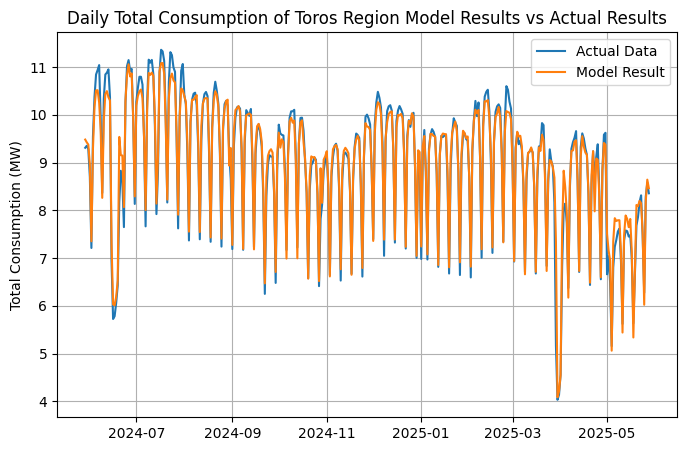

In [ ]:
# Here we compare the results with the model for the entire Toros Regions

# Plot
plt.figure(figsize=(8, 5))
plt.plot(df_toros_agg['DATE'], df_toros_agg['TotalConsumption']/MW, label='Actual Data')
plt.plot(df_model_total['DATE'], df_model_total['TotalConsumption']/MW, label='Model Result')

plt.ylabel('Total Consumption (MW)')
plt.title('Daily Total Consumption of Toros Region Model Results vs Actual Results')
plt.legend()
plt.grid(True)
plt.show()

##4.1 Daily Distributions for each day type

In [ ]:
# Here we calculate a normalized distribution for every day
for index, hour in enumerate(consumption_hours):
  df_toros_agg[index] = df_toros_agg[hour] / df_toros_agg['TotalConsumption']

# List of hours
hours = list(range(0, 24))  # 0 to 23
# Here we create another dataframe to store the average distribution
df_daily_dist = df_toros_agg.groupby('NEW_DAY_TYPE')[hours].mean().reset_index()
df_daily_dist.head(20)

,NEW_DAY_TYPE,0,1,2,3,4,5,6,7,8,...,14,15,16,17,18,19,20,21,22,23
0,1,0.029000,0.028953,0.028732,0.028538,0.028696,0.029213,0.030853,0.038284,0.049355,...,0.053196,0.052601,0.051203,0.047536,0.043349,0.042453,0.042411,0.041712,0.040339,0.038795
1,2,0.034607,0.034627,0.034261,0.033898,0.033626,0.033799,0.034508,0.040116,0.049067,...,0.050051,0.049536,0.048266,0.044911,0.040991,0.040115,0.040076,0.039418,0.038117,0.036733
2,3,0.034559,0.034563,0.034169,0.033788,0.033539,0.033753,0.034392,0.039891,0.048791,...,0.050220,0.049731,0.048410,0.045080,0.041075,0.040265,0.040179,0.039499,0.038228,0.036790
3,4,0.034712,0.034761,0.034346,0.033989,0.033743,0.033942,0.034628,0.040173,0.048973,...,0.050000,0.049411,0.048216,0.044914,0.040948,0.040117,0.040082,0.039422,0.038155,0.036788
4,5,0.035271,0.035296,0.034890,0.034458,0.034176,0.034381,0.035002,0.040476,0.049203,...,0.049859,0.049326,0.047962,0.044769,0.040966,0.040092,0.040034,0.039371,0.038016,0.036519
5,6,0.038229,0.038241,0.037779,0.037269,0.037040,0.036945,0.036769,0.040700,0.047198,...,0.046234,0.045443,0.044778,0.043303,0.041075,0.040905,0.041059,0.040405,0.038972,0.037335
6,7,0.044288,0.044283,0.043759,0.043076,0.042409,0.041556,0.039704,0.039337,0.040189,...,0.042269,0.042349,0.042481,0.042310,0.041873,0.042523,0.042749,0.042105,0.040664,0.039507
7,8,0.036082,0.036072,0.035595,0.035182,0.035013,0.035035,0.035067,0.038660,0.045131,...,0.047991,0.047909,0.047453,0.045643,0.042479,0.042238,0.042787,0.042002,0.040664,0.039133
8,9,0.038916,0.037905,0.037107,0.037008,0.036753,0.036247,0.036051,0.037485,0.040044,...,0.045210,0.044960,0.044500,0.044501,0.044761,0.045668,0.045717,0.044779,0.042915,0.041729
9,10,0.034067,0.033855,0.033551,0.033145,0.032834,0.032390,0.032130,0.036210,0.044978,...,0.050473,0.049928,0.048544,0.045955,0.042719,0.042605,0.043721,0.043256,0.041631,0.039762


In [ ]:
# Here we calculate the daily model distribution

# First we need to add Day Type to the model results
df_model_total = pd.merge(df_toros_agg[['DATE', 'NEW_DAY_TYPE']], df_model_total, on='DATE', how='left')

# Then we add the distribution for each day
df_model_total = pd.merge(df_model_total, df_daily_dist, on='NEW_DAY_TYPE', how='left')

# Here we calculate the hourly consumption by calculating the distribution for each day
for index, hour in enumerate(consumption_hours):
  df_model_total[hour] = df_model_total[index] * df_model_total['TotalConsumption']


df_model_total.head()

,DATE,NEW_DAY_TYPE,TotalConsumption,0,1,2,3,4,5,6,...,ConsumptionH15,ConsumptionH16,ConsumptionH17,ConsumptionH18,ConsumptionH19,ConsumptionH20,ConsumptionH21,ConsumptionH22,ConsumptionH23,ConsumptionH24
0,2024-05-29,3,9.483526e+06,0.034559,0.034563,0.034169,0.033788,0.033539,0.033753,0.034392,...,476258.935251,471624.125673,459093.823037,427514.950570,389532.280600,381855.645191,381042.628938,374588.166426,362532.626041,348894.535945
1,2024-05-30,4,9.425584e+06,0.034712,0.034761,0.034346,0.033989,0.033743,0.033942,0.034628,...,471275.770526,465729.536580,454461.901491,423342.455125,385957.225949,378124.377914,377796.284116,371574.849564,359631.116005,346747.093050
2,2024-05-31,5,9.378988e+06,0.035271,0.035296,0.034890,0.034458,0.034176,0.034381,0.035002,...,467624.209219,462630.410653,449836.751200,419890.982911,384218.575337,376025.015250,375482.640344,369257.190341,356555.835537,342509.602668
3,2024-06-01,6,8.957819e+06,0.038229,0.038241,0.037779,0.037269,0.037040,0.036945,0.036769,...,414151.670915,407069.660926,401116.720696,387897.051398,367941.405729,366420.851433,367798.323227,361937.305196,349108.299759,334436.541212
4,2024-06-02,7,7.352141e+06,0.044288,0.044283,0.043759,0.043076,0.042409,0.041556,0.039704,...,310766.677863,311357.190674,312322.686160,311070.472104,307853.082481,312638.172068,314297.214808,309564.963056,298968.252827,290459.965287


(150000.0, 600000.0)

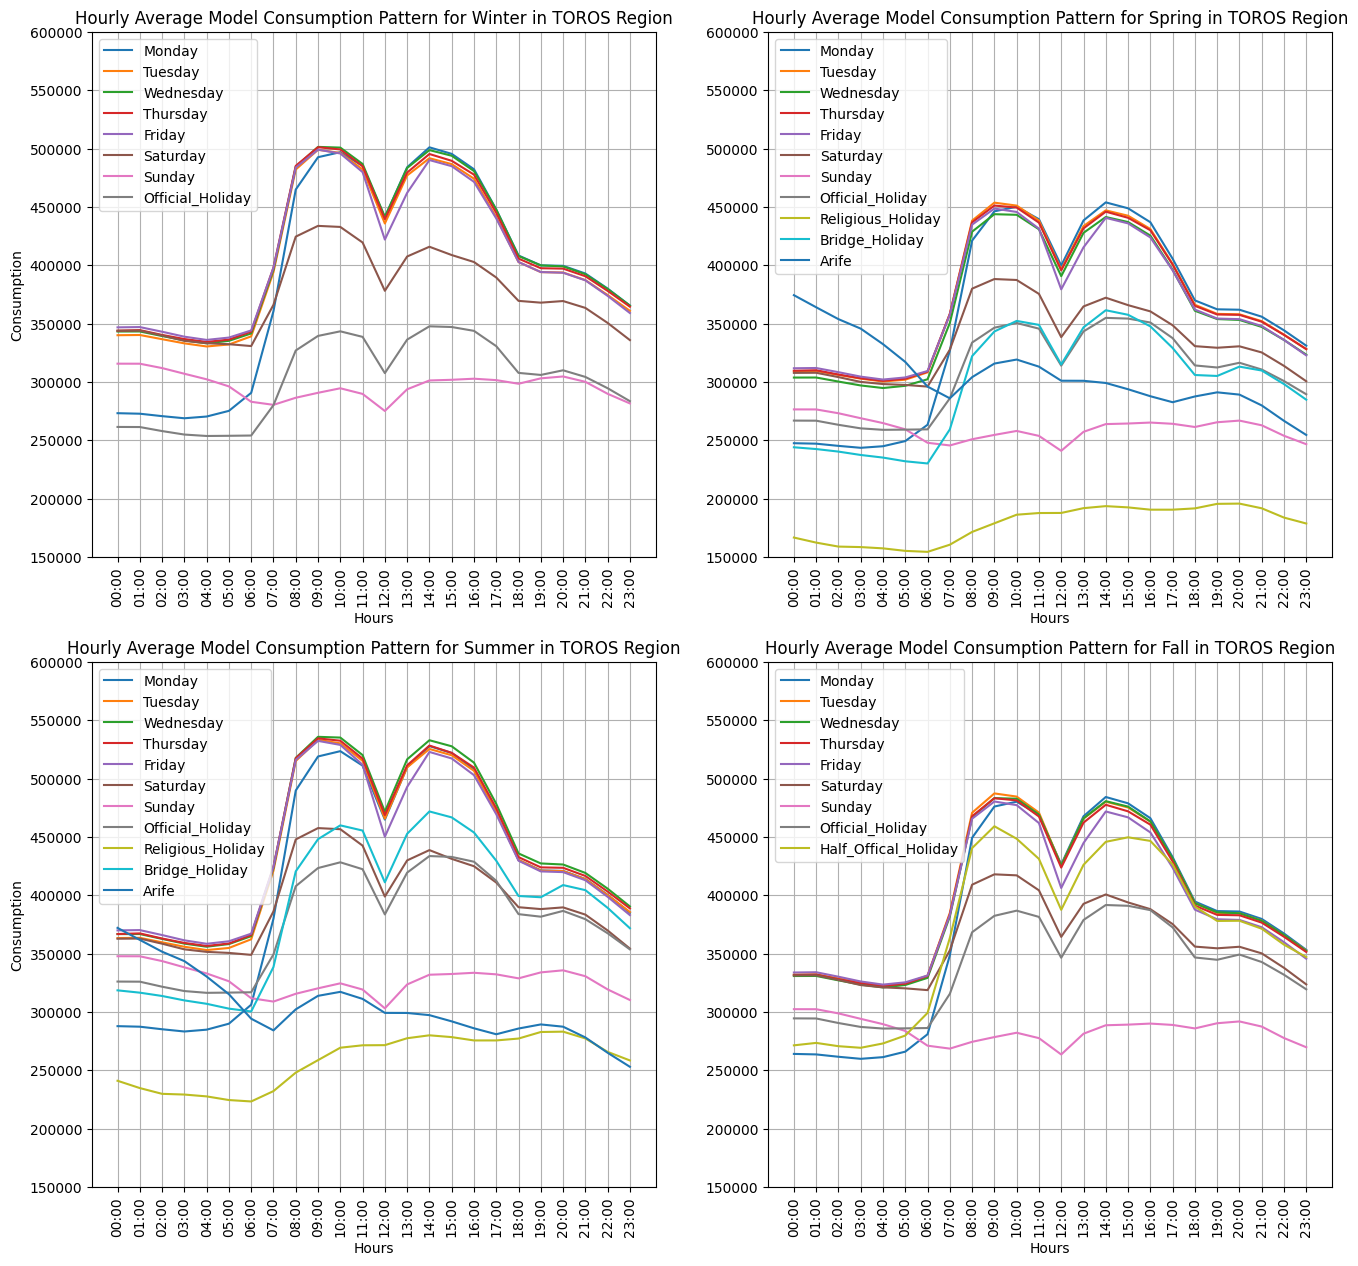

In [ ]:
# Here we create the daily distribution average of the model results for each season

# Extract numeric month
df_model_total['MONTH'] = df_model_total['DATE'].dt.month

# Here we create a SEASON column for the data imputation
df_model_total['SEASON'] = df_model_total['MONTH'].apply(get_season)

# Here we create hours for our plots
hours = [f'{h:02d}:00' for h in range(24)]
# Here we aggregate data for TOROS region to check patterns for each day type and month
agg_columns = ['NEW_DAY_TYPE', 'SEASON']
# Sum consumption based on cities
df_model_total_season = df_model_total.groupby(agg_columns)[consumption_hours].mean().reset_index()
# Group into dictionary: Category → list of Items
day_type_map = df_takvim[['NEW_DAY_TYPE', 'NEW_DAY_TYPE_TXT']].drop_duplicates().groupby('NEW_DAY_TYPE')['NEW_DAY_TYPE_TXT'].apply(list).to_dict()
# Transform the data for Winter (SEASON 1)
df_winter = transform_consumption_dataframe(df_model_total_season, 1, consumption_hours)
# Transform the data for Spring (SEASON 2)
df_spring = transform_consumption_dataframe(df_model_total_season, 2, consumption_hours)
# Transform the data for Summer (SEASON 3)
df_summer = transform_consumption_dataframe(df_model_total_season, 3, consumption_hours)
# Transform the data for Fall (SEASON 4)
df_fall = transform_consumption_dataframe(df_model_total_season, 4, consumption_hours)

# Iterate through unique combinations of NEW_DAY_TYPE and SEASON
fig, axes = plt.subplots(2, 2, figsize=(16, 15))

# Plot Winter Season
for col in df_winter.columns:
  axes[0, 0].plot(df_winter.index, df_winter[col], label=day_type_map[col])
# Here we arrange the subplot axis and legends
axes[0, 0].set_title('Hourly Average Model Consumption Pattern for Winter in TOROS Region')
axes[0, 0].set_ylabel('Consumption')
axes[0, 0].set_xticks(range(len(hours)))
axes[0, 0].set_xticklabels(hours, rotation=90)
axes[0, 0].legend()
axes[0, 0].grid(True)
axes[0, 0].set_xlabel('Hours')
axes[0, 0].set_ylim(150000, 600000)  # Set y-axis limit

# Plot Spring Season
for col in df_spring.columns:
  axes[0, 1].plot(df_spring.index, df_spring[col], label=day_type_map[col])
# Here we arrange the subplot axis and legends
axes[0, 1].set_title('Hourly Average Model Consumption Pattern for Spring in TOROS Region')
axes[0, 1].set_xticks(range(len(hours)))
axes[0, 1].set_xticklabels(hours, rotation=90)
axes[0, 1].legend()
axes[0, 1].grid(True)
axes[0, 1].set_xlabel('Hours')
axes[0, 1].set_ylim(150000, 600000)  # Set y-axis limit

# Plot Summer Season
for col in df_summer.columns:
  axes[1, 0].plot(df_summer.index, df_summer[col], label=day_type_map[col])
# Here we arrange the subplot axis and legends
axes[1, 0].set_title('Hourly Average Model Consumption Pattern for Summer in TOROS Region')
axes[1, 0].set_ylabel('Consumption')
axes[1, 0].set_xticks(range(len(hours)))
axes[1, 0].set_xticklabels(hours, rotation=90)
axes[1, 0].legend()
axes[1, 0].grid(True)
axes[1, 0].set_xlabel('Hours')
axes[1, 0].set_ylim(150000, 600000)  # Set y-axis limit

# Plot Fall Season
for col in df_fall.columns:
  axes[1, 1].plot(df_summer.index, df_fall[col], label=day_type_map[col])
# Here we arrange the subplot axis and legends
axes[1, 1].set_title('Hourly Average Model Consumption Pattern for Fall in TOROS Region')
axes[1, 1].set_xticks(range(len(hours)))
axes[1, 1].set_xticklabels(hours, rotation=90)
axes[1, 1].legend()
axes[1, 1].grid(True)
axes[1, 1].set_xlabel('Hours')
axes[1, 1].set_ylim(150000, 600000)  # Set y-axis limit

#5. Forecast for the next two weeks

In [ ]:
# Here we arrange the inputs for the forecast
df_meteo_forecast = df_meteo[df_meteo['Forecast/Actual'] == 'Forecast']
# Here we format the date
df_meteo_forecast['Date'] = pd.to_datetime(df_meteo_forecast['Date'], format='%d.%m.%Y')
# Here we aggregate data for date and city
agg_columns = ['Date',  'Location']
# Here we list the columns where we take the average
feature_columns = ['RelativeHumidity',  'WindSpeed',
                   'EffectiveCloudCover',    'Precipitationheight','Temp_Diff']
# Mean weather conditions based on cities and date
df_meteo_forecast = df_meteo_forecast.groupby(agg_columns)[feature_columns].mean().reset_index()

df_meteo_forecast.head()

/tmp/ipython-input-47-906297776.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_meteo_forecast['Date'] = pd.to_datetime(df_meteo_forecast['Date'], format='%d.%m.%Y')


,Date,Location,RelativeHumidity,WindSpeed,EffectiveCloudCover,Precipitationheight,Temp_Diff
0,2025-05-29,Adana,79.916667,2.775000,5.504167,0.441667,-4.145833
1,2025-05-29,Ankara,56.291667,1.520833,4.254167,0.183333,-0.208333
2,2025-05-29,Gaziantep,53.041667,3.437500,2.050000,0.037500,-0.733333
3,2025-05-29,Hatay,66.291667,7.087500,3.095833,0.062500,-3.533333
4,2025-05-29,Istanbulasia,60.625000,0.779167,1.845833,0.000000,-1.375000


In [ ]:
print(day_type_map)

{1: ['Monday'], 2: ['Tuesday'], 3: ['Wednesday'], 4: ['Thursday'], 5: ['Friday'], 6: ['Saturday'], 7: ['Sunday'], 8: ['Official_Holiday'], 9: ['Religious_Holiday'], 10: ['Bridge_Holiday'], 11: ['Arife'], 12: ['Half_Offical_Holiday']}


In [ ]:
# Here we check if any day in our forecast is a holiday
import holidays

# Load Turkey holidays
turkish_holidays = holidays.Turkey()

# Here we create a date dataframe to map holidays and weekdays for the forecast
df_forecast_days = pd.DataFrame({
    'Date' : df_meteo_forecast['Date'].unique(),
    'NEW_DAY_TYPE' : df_meteo_forecast['Date'].unique().weekday
})
# Here we shift the numbering
df_forecast_days['NEW_DAY_TYPE'] = df_forecast_days['NEW_DAY_TYPE'] + 1

# Here we create index list
index_list = []

# Here we create a list to store dates and
for index, day in enumerate(df_forecast_days['Date']):
  # Check if it's a holiday
  if day in turkish_holidays:
      print(f"{day} is a holiday: {turkish_holidays[day]}")
      # Here we add it to index list
      index_list.append(index)
  else:
      print(f"{day} is not a holiday.")

# Here we change the day type based on the index list
df_forecast_days.loc[index_list, 'NEW_DAY_TYPE'] = 9
# Here we update Arife day type
df_forecast_days.loc[index_list[0]-1, 'NEW_DAY_TYPE'] = 11

df_forecast_days.head(20)

2025-05-29 00:00:00 is not a holiday.
2025-05-30 00:00:00 is not a holiday.
2025-05-31 00:00:00 is not a holiday.
2025-06-01 00:00:00 is not a holiday.
2025-06-02 00:00:00 is not a holiday.
2025-06-03 00:00:00 is not a holiday.
2025-06-04 00:00:00 is not a holiday.
2025-06-05 00:00:00 is not a holiday.
2025-06-06 00:00:00 is a holiday: Eid al-Adha
2025-06-07 00:00:00 is a holiday: Eid al-Adha
2025-06-08 00:00:00 is a holiday: Eid al-Adha
2025-06-09 00:00:00 is a holiday: Eid al-Adha
2025-06-10 00:00:00 is not a holiday.
2025-06-11 00:00:00 is not a holiday.


,Date,NEW_DAY_TYPE
0,2025-05-29,4
1,2025-05-30,5
2,2025-05-31,6
3,2025-06-01,7
4,2025-06-02,1
5,2025-06-03,2
6,2025-06-04,3
7,2025-06-05,11
8,2025-06-06,9
9,2025-06-07,9


In [ ]:
# Here we merge it with weather data
df_meteo_forecast = pd.merge(df_meteo_forecast, df_forecast_days, on='Date', how='left')

# Extract numeric month
df_meteo_forecast['MONTH'] = df_meteo_forecast['Date'].dt.month

# The day of the year
df_meteo_forecast['DayOfYear'] = df_meteo_forecast['Date'].dt.dayofyear
df_meteo_forecast.head()

,Date,Location,RelativeHumidity,WindSpeed,EffectiveCloudCover,Precipitationheight,Temp_Diff,NEW_DAY_TYPE,MONTH,DayOfYear
0,2025-05-29,Adana,79.916667,2.775000,5.504167,0.441667,-4.145833,4,5,149
1,2025-05-29,Ankara,56.291667,1.520833,4.254167,0.183333,-0.208333,4,5,149
2,2025-05-29,Gaziantep,53.041667,3.437500,2.050000,0.037500,-0.733333,4,5,149
3,2025-05-29,Hatay,66.291667,7.087500,3.095833,0.062500,-3.533333,4,5,149
4,2025-05-29,Istanbulasia,60.625000,0.779167,1.845833,0.000000,-1.375000,4,5,149


In [ ]:
# Here we create dummy columns for Days
# Initialize the One Hot Encoder
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the 'NEW_DAY_TYPE' column
encoded_days = encoder.fit_transform(df_meteo_forecast[['NEW_DAY_TYPE']])

# Get column names from encoder
encoded_cols = encoder.get_feature_names_out(['NEW_DAY_TYPE'])

# Create DataFrame of encoded columns
df_encoded = pd.DataFrame(encoded_days, columns=encoded_cols, index=df_meteo_forecast.index)

# Here we merge the encoded days
df_meteo_forecast = pd.concat([df_meteo_forecast, df_encoded], axis=1)

df_meteo_forecast.head()

,Date,Location,RelativeHumidity,WindSpeed,EffectiveCloudCover,Precipitationheight,Temp_Diff,NEW_DAY_TYPE,MONTH,DayOfYear,NEW_DAY_TYPE_1,NEW_DAY_TYPE_2,NEW_DAY_TYPE_3,NEW_DAY_TYPE_4,NEW_DAY_TYPE_5,NEW_DAY_TYPE_6,NEW_DAY_TYPE_7,NEW_DAY_TYPE_9,NEW_DAY_TYPE_11
0,2025-05-29,Adana,79.916667,2.775000,5.504167,0.441667,-4.145833,4,5,149,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2025-05-29,Ankara,56.291667,1.520833,4.254167,0.183333,-0.208333,4,5,149,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2025-05-29,Gaziantep,53.041667,3.437500,2.050000,0.037500,-0.733333,4,5,149,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,2025-05-29,Hatay,66.291667,7.087500,3.095833,0.062500,-3.533333,4,5,149,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2025-05-29,Istanbulasia,60.625000,0.779167,1.845833,0.000000,-1.375000,4,5,149,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Here we create dummy columns for Months
# Initialize the One Hot Encoder
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the 'MONTH' column
encoded_days = encoder.fit_transform(df_meteo_forecast[['MONTH']])

# Get column names from encoder
encoded_cols = encoder.get_feature_names_out(['MONTH'])

# Create DataFrame of encoded columns
df_encoded = pd.DataFrame(encoded_days, columns=encoded_cols, index=df_meteo_forecast.index)

# Here we merge the encoded days
df_meteo_forecast = pd.concat([df_meteo_forecast, df_encoded], axis=1)

df_meteo_forecast.head()

,Date,Location,RelativeHumidity,WindSpeed,EffectiveCloudCover,Precipitationheight,Temp_Diff,NEW_DAY_TYPE,MONTH,DayOfYear,...,NEW_DAY_TYPE_2,NEW_DAY_TYPE_3,NEW_DAY_TYPE_4,NEW_DAY_TYPE_5,NEW_DAY_TYPE_6,NEW_DAY_TYPE_7,NEW_DAY_TYPE_9,NEW_DAY_TYPE_11,MONTH_5,MONTH_6
0,2025-05-29,Adana,79.916667,2.775000,5.504167,0.441667,-4.145833,4,5,149,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2025-05-29,Ankara,56.291667,1.520833,4.254167,0.183333,-0.208333,4,5,149,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2025-05-29,Gaziantep,53.041667,3.437500,2.050000,0.037500,-0.733333,4,5,149,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2025-05-29,Hatay,66.291667,7.087500,3.095833,0.062500,-3.533333,4,5,149,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2025-05-29,Istanbulasia,60.625000,0.779167,1.845833,0.000000,-1.375000,4,5,149,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df_city_w_weather.head()

,DATE,Sehir,TotalConsumption,RelativeHumidity,WindSpeed,EffectiveCloudCover,Precipitationheight,Temp_Diff,DayOfYear,NEW_DAY_TYPE_1,...,MONTH_3,MONTH_4,MONTH_5,MONTH_6,MONTH_7,MONTH_8,MONTH_9,MONTH_10,MONTH_11,MONTH_12
0,2024-05-29,Adana,2.479789e+06,76.295833,2.675000,3.083333,0.004167,-4.966667,150,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-05-29,Ankara,1.305383e+04,67.066667,0.712500,2.491667,0.000000,-0.562500,150,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,2024-05-29,Gaziantep,2.224746e+06,47.358333,2.441667,0.000000,0.000000,0.112500,150,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13,2024-05-29,Hatay,1.077005e+06,67.316667,6.325000,4.000000,0.000000,-3.687500,150,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15,2024-05-29,Istanbulasia,1.580244e+04,58.737500,0.637500,0.375000,0.000000,-1.562500,150,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# df_city_w_weather columns
print(df_city_w_weather.columns)

# Here we add non-existing columns with zero entry
for col in df_city_w_weather.columns[9:]:
    if col not in df_meteo_forecast.columns:
        df_meteo_forecast[col] = 0
# Here we drop unused columns
df_meteo_forecast.drop(columns=['NEW_DAY_TYPE', 'MONTH'], inplace = True)
# Here we rename the columns
df_meteo_forecast.rename(columns={'Location': 'Sehir', 'Date': 'DATE'}, inplace=True)
# Here we create list of columns to be reordered
cols = list(df_city_w_weather.columns)
cols.remove('TotalConsumption')
# Here we reorder columns
df_meteo_forecast = df_meteo_forecast[cols]
df_meteo_forecast.head()

Index(['DATE', 'Sehir', 'TotalConsumption', 'RelativeHumidity', 'WindSpeed',
       'EffectiveCloudCover', 'Precipitationheight', 'Temp_Diff', 'DayOfYear',
       'NEW_DAY_TYPE_1', 'NEW_DAY_TYPE_2', 'NEW_DAY_TYPE_3', 'NEW_DAY_TYPE_4',
       'NEW_DAY_TYPE_5', 'NEW_DAY_TYPE_6', 'NEW_DAY_TYPE_7', 'NEW_DAY_TYPE_8',
       'NEW_DAY_TYPE_9', 'NEW_DAY_TYPE_10', 'NEW_DAY_TYPE_11',
       'NEW_DAY_TYPE_12', 'MONTH_1', 'MONTH_2', 'MONTH_3', 'MONTH_4',
       'MONTH_5', 'MONTH_6', 'MONTH_7', 'MONTH_8', 'MONTH_9', 'MONTH_10',
       'MONTH_11', 'MONTH_12'],
      dtype='object')


,DATE,Sehir,RelativeHumidity,WindSpeed,EffectiveCloudCover,Precipitationheight,Temp_Diff,DayOfYear,NEW_DAY_TYPE_1,NEW_DAY_TYPE_2,...,MONTH_3,MONTH_4,MONTH_5,MONTH_6,MONTH_7,MONTH_8,MONTH_9,MONTH_10,MONTH_11,MONTH_12
0,2025-05-29,Adana,79.916667,2.775000,5.504167,0.441667,-4.145833,149,0.0,0.0,...,0,0,1.0,0.0,0,0,0,0,0,0
1,2025-05-29,Ankara,56.291667,1.520833,4.254167,0.183333,-0.208333,149,0.0,0.0,...,0,0,1.0,0.0,0,0,0,0,0,0
2,2025-05-29,Gaziantep,53.041667,3.437500,2.050000,0.037500,-0.733333,149,0.0,0.0,...,0,0,1.0,0.0,0,0,0,0,0,0
3,2025-05-29,Hatay,66.291667,7.087500,3.095833,0.062500,-3.533333,149,0.0,0.0,...,0,0,1.0,0.0,0,0,0,0,0,0
4,2025-05-29,Istanbulasia,60.625000,0.779167,1.845833,0.000000,-1.375000,149,0.0,0.0,...,0,0,1.0,0.0,0,0,0,0,0,0


In [ ]:
# Here we create an empty dataframe to store the model results
df_forecast_w_weather = pd.DataFrame()
df_forecast_w_weather['DATE'] = df_meteo_forecast['DATE'].unique()

# Here we forecast the consumption for cities with the weather data
for city in df_meteo_forecast['Sehir'].unique():
  # Here we separate inputs for each city
  df_city = df_meteo_forecast[df_meteo_forecast['Sehir'] == city]
  X = df_city.drop(columns=['DATE', 'Sehir'])         # Features
  # Here we fit the model
  df_forecast_w_weather[city] = gb_models[city].predict(X)

df_forecast_w_weather.head()

,DATE,Adana,Ankara,Gaziantep,Hatay,Istanbulasia,Istanbuleurope,Mersin,Zonguldak
0,2025-05-29,2.416994e+06,13116.006924,1.573524e+06,1.041268e+06,14326.872514,9091.372166,1.422644e+06,154.765732
1,2025-05-30,2.367388e+06,13208.491987,2.226584e+06,1.051492e+06,15690.074721,6603.676411,1.412556e+06,154.756888
2,2025-05-31,2.316764e+06,11709.992906,2.055253e+06,1.005174e+06,15151.726843,5837.118324,1.356945e+06,163.983918
3,2025-06-01,2.128852e+06,11654.733144,1.806650e+06,8.603681e+05,13899.400776,5750.638464,1.076207e+06,153.547474
4,2025-06-02,2.375019e+06,11741.965443,2.087965e+06,9.913108e+05,14855.337430,6475.341814,1.355788e+06,159.044426


In [ ]:
# Here we forecast the consumption for the cities without the weather data

# Here we create an empty dataframe to store the model results
df_forecast_wo_weather = pd.DataFrame()
df_forecast_wo_weather['DATE'] = df_meteo_forecast['DATE'].unique()

# Here we create X variable for all cities without the weather data
df_city = df_meteo_forecast[df_meteo_forecast['Sehir'] == 'Ankara'] # Note that it does not matter which city we pick if there is no weather forecast
X = df_city.drop(columns=['DATE', 'Sehir', 'RelativeHumidity',	'WindSpeed',
                          'EffectiveCloudCover',	'Precipitationheight',	'Temp_Diff' ])         # Features

for city in df_city_wo_weather['Sehir'].unique():
  # Here we fit the model
  df_forecast_wo_weather[city] = gb_models[city].predict(X)

df_forecast_wo_weather.head()

,DATE,Amasya,Antalya,Bingol,Bitlis,Bursa,Cankiri,Diyarbakir,Edirne,Elazig,...,Afyonkarahisar,Malatya,Aksaray,Kastamonu,Kirsehir,Hakkari,Mus,Van,Aydin,Yozgat
0,2025-05-29,30641.382747,848233.836508,5205.640131,312.908263,212.214531,218.435557,6482.880162,582.990595,120895.388870,...,385.437088,7788.964456,2761.462597,655.451391,3982.817345,18816.388446,3433.963662,91164.069410,-0.001773,925.018964
1,2025-05-30,36154.370334,708490.149818,115.351719,310.937953,251.882066,217.946533,6429.231302,584.442033,123705.052720,...,370.020123,7843.206175,2747.751656,655.451391,3987.484934,18816.388446,3433.963662,91190.251996,0.002818,718.192523
2,2025-05-31,36154.370334,708848.229896,91.318045,271.664469,243.917109,221.408925,6816.230164,598.671590,116420.293021,...,313.941066,1756.901788,2785.860174,647.538658,3837.601150,18702.747740,3415.955346,89291.727918,-0.006923,842.635286
3,2025-06-01,36154.370334,678311.364025,63.362110,319.583813,239.307493,198.278912,6749.928944,687.999397,118573.005080,...,276.714825,1790.365576,1699.297415,576.022411,3695.705838,17812.350121,3209.629060,84186.672180,-0.000387,540.399635
4,2025-06-02,36154.370334,704785.076723,81.019558,293.848024,234.122457,208.346682,6916.639739,697.239285,118602.392223,...,321.553835,1790.365576,2738.634364,663.458937,3739.816256,18528.775500,3367.959114,89315.733391,-0.000387,811.797463


In [ ]:
# Here we sum the consumption in all cities in Toros regions

df_forecast_w_weather['TotalConsumption'] = df_forecast_w_weather[list_of_weather].sum(axis=1)
df_forecast_wo_weather['TotalConsumption'] = df_forecast_wo_weather[df_city_wo_weather['Sehir'].unique().tolist( )].sum(axis=1)

# Here we create an empty dataframe to store the total model results
df_forecast_total = pd.DataFrame()
df_forecast_total['DATE'] = df_forecast_w_weather['DATE']
df_forecast_total['TotalConsumption'] = df_forecast_w_weather['TotalConsumption'] + df_forecast_wo_weather['TotalConsumption']

df_forecast_total.head()

,DATE,TotalConsumption
0,2025-05-29,8.648115e+06
1,2025-05-30,9.313791e+06
2,2025-05-31,8.947848e+06
3,2025-06-01,7.922204e+06
4,2025-06-02,8.971046e+06


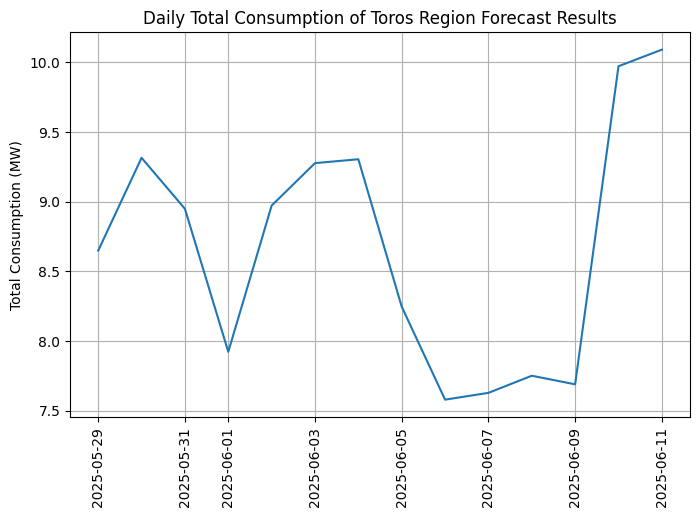

In [ ]:
# Here we compare the results with the model for the entire Toros Regions

# Plot
plt.figure(figsize=(8, 5))
plt.plot(df_forecast_total['DATE'], df_forecast_total['TotalConsumption']/MW)

plt.ylabel('Total Consumption (MW)')
plt.title('Daily Total Consumption of Toros Region Forecast Results')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

#4.1 Daily Distribution of Forecast

In [ ]:
#Here we we combine the forecast data with the day type we created for the forecast days

# Here we merge the day type with forecast data
df_forecast_total = pd.merge(df_forecast_total, df_forecast_days, left_on='DATE', right_on='Date', how='left')
# Here we drop the extra date column
df_forecast_total.drop(columns=['Date'], inplace=True)
# Here we merge the forecast data with daily distribution
df_forecast_total = pd.merge(df_forecast_total, df_daily_dist, on='NEW_DAY_TYPE', how='left')
# Here we calculate the hourly consumption by calculating the distribution for each day
for index, hour in enumerate(consumption_hours):
  df_forecast_total[hour] = df_forecast_total[index] * df_forecast_total['TotalConsumption']

df_forecast_total.head()

,DATE,TotalConsumption,NEW_DAY_TYPE,0,1,2,3,4,5,6,...,ConsumptionH15,ConsumptionH16,ConsumptionH17,ConsumptionH18,ConsumptionH19,ConsumptionH20,ConsumptionH21,ConsumptionH22,ConsumptionH23,ConsumptionH24
0,2025-05-29,8.648115e+06,4,0.034712,0.034761,0.034346,0.033989,0.033743,0.033942,0.034628,...,432402.600683,427313.847702,416975.623205,388423.063574,354121.554067,346934.798302,346633.767312,340925.507629,329966.952627,318145.667974
1,2025-05-30,9.313791e+06,5,0.035271,0.035296,0.034890,0.034458,0.034176,0.034381,0.035002,...,464373.587232,459414.502333,446709.776152,416972.171536,381547.735538,373411.131798,372872.527133,366690.352444,354077.289269,340128.696754
2,2025-05-31,8.947848e+06,6,0.038229,0.038241,0.037779,0.037269,0.037040,0.036945,0.036769,...,413690.670401,406616.543540,400670.229647,387465.275427,367531.842787,366012.981050,367388.919553,361534.425538,348719.700324,334064.273204
3,2025-06-01,7.922204e+06,7,0.044288,0.044283,0.043759,0.043076,0.042409,0.041556,0.039704,...,334862.608908,335498.908340,336539.265496,335189.958458,331723.101939,336879.213250,338666.893269,333567.716681,322149.368815,312981.373769
4,2025-06-02,8.971046e+06,1,0.029000,0.028953,0.028732,0.028538,0.028696,0.029213,0.030853,...,477227.545566,471884.804584,459344.986986,426446.481375,388885.306952,380844.423410,380468.757405,374196.633412,361884.794240,348034.800686


In [ ]:
def transform_dataframe(df_forecast_total, consumption_hours):
  """
    This function transposes and formats the forecast dataframe for a given season.
  """
  # Here we create hours for our plots
  hours = [f'{h:02d}:00' for h in range(24)]
  # Here we initialize the list to store transposed dataframes for each day type
  transposed_dfs = []

  # Iterate through unique day types for the given season
  for day_type in df_forecast_total['NEW_DAY_TYPE'].unique():
      # Filter for the current day type
      filtered_df = df_forecast_total[df_forecast_total['NEW_DAY_TYPE'] == day_type][consumption_hours].T.reset_index()
      # Rename the consumption column
      filtered_df.columns = ['Hour', day_type]
      transposed_dfs.append(filtered_df)

  # Merge the transposed dataframes on the 'Hour' column
  if transposed_dfs:
      df_season = transposed_dfs[0]
      for i in range(1, len(transposed_dfs)):
          df_season = pd.merge(df_season, transposed_dfs[i], on='Hour')
      # Here we set hours to actual hours
      df_season['Hour'] = hours
      # Set 'Hour' as the index
      df_season.set_index('Hour', inplace=True)
      return df_season
  else:
      return pd.DataFrame({'Hour': hours}) # Return a dataframe with just hours if no data

(150000.0, 600000.0)

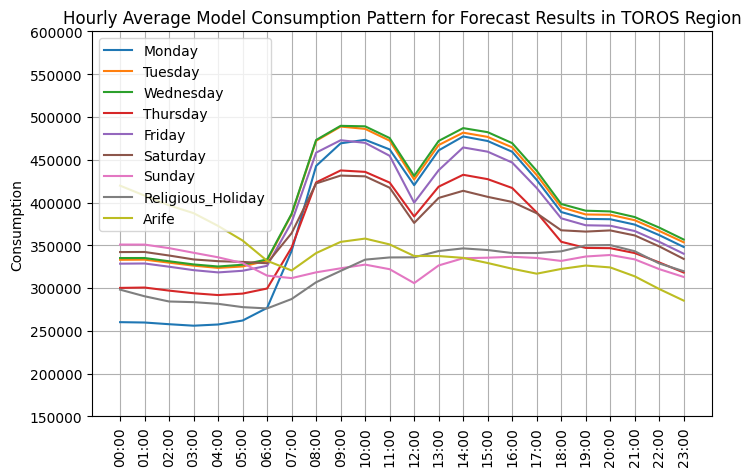

In [ ]:
# Here we plot the data for each day type in the forecast

# Here we aggregate data for TOROS region to check patterns for each day type and month
agg_columns = ['NEW_DAY_TYPE']
# Sum consumption based on Day Type
df_forecast_days = df_forecast_total.groupby(agg_columns)[consumption_hours].mean().reset_index()
# Transform the data
df_forecast_transform = transform_dataframe(df_forecast_days, consumption_hours)

# Iterate through unique combinations of NEW_DAY_TYPE
plt.figure(figsize=(8, 5))

# Plot Forecast Data
for col in df_forecast_transform.columns:
  plt.plot(df_forecast_transform.index, df_forecast_transform[col], label=day_type_map[col])
# Here we arrange the subplot axis and legends
plt.title('Hourly Average Model Consumption Pattern for Forecast Results in TOROS Region')
plt.ylabel('Consumption')
plt.xticks(range(len(hours)), rotation = 90)
plt.legend()
plt.grid(True)
plt.ylim(150000, 600000)  # Set y-axis limit

In [ ]:
# Here we create the dataframe for the hourly forecast type
df_predictions = pd.DataFrame() # Empty dataframe to fill

# Iterate through each day
for date in df_forecast_total['DATE'].unique():
    # Filter for the current day type
    df_transformed = df_forecast_total[df_forecast_total['DATE'] == date][consumption_hours].T.reset_index()
    # Format without leading zeros
    formatted_date = f"{date.month}/{date.day}/{date.year}"
    # Here we create DateTime column entries
    hours = [f'{formatted_date} {h:02d}:00' for h in range(24)]
    df_transformed['index'] = hours
    # Here we rename the columns
    df_transformed.columns = ['DateTime', 'Consumption_Forecast']
    # Add df_transformed rows to df_predictions
    df_predictions = pd.concat([df_predictions, df_transformed], ignore_index=True)


df_predictions.head(24)

,DateTime,Consumption_Forecast
0,5/29/2025 00:00,300192.932765
1,5/29/2025 01:00,300620.030235
2,5/29/2025 02:00,297025.454574
3,5/29/2025 03:00,293939.715935
4,5/29/2025 04:00,291816.643925
5,5/29/2025 05:00,293533.614329
6,5/29/2025 06:00,299470.208787
7,5/29/2025 07:00,347418.883702
8,5/29/2025 08:00,423528.279853
9,5/29/2025 09:00,437479.699670


In [ ]:
!pip install openpyxl
!pip install XlsxWriter
# Write with xlsxwriter to control column width
with pd.ExcelWriter('Prediction.xlsx', engine='xlsxwriter') as writer:
    df_predictions.to_excel(writer, sheet_name='Sheet1', index=False)

    # Get the workbook and worksheet objects
    workbook  = writer.book
    worksheet = writer.sheets['Sheet1']

    # Set column widths based on max length in each column
    for i, col in enumerate(df_predictions.columns):
        # Get the max length between column name and data
        column_len = max(
            df_predictions[col].astype(str).map(len).max(),
            len(col)
        ) + 2  # add a little padding
        worksheet.set_column(i, i, column_len)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 3.4 MB/s eta 0:00:00
